In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import logging
import warnings
from pathlib import Path
from scipy.optimize import minimize
from scipy.spatial.distance import mahalanobis
from scipy.linalg import inv
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AffinityPropagation
from scipy.spatial.distance import cdist
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, average_precision_score
import shap
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")
log = logging.getLogger(__name__)

# Import data

In [2]:
# ── 1. Laden & Datum konvertieren ──────────────────────────────────────
analysis_df = pd.read_excel('analysis_df.xlsx')

analysis_df['TIME'] = pd.to_datetime(
    analysis_df['TIME'].str.replace('-M', '-', regex=False),
    format='%Y-%m'
)

In [3]:
# drop countries with specific debt information
countries_to_drop = [
    'Congo, Dem. Rep. (Zaire)',
    'Congo, Rep.',
    'Dominican Rep.',
    'Dominican Rep. (bond debt)',
    'Dominican Rep. (bank debt)',
    'Ethopia',
    'Gambia,The',
    'Moldova (Gazprom debt)',
    'Mozambique (EMATUM Notes)',
    'Mozambique (Eurobonds)',
    'Other Countries n.i.e.',
    'Pakistan (bond debt)',
    'Panama (bond debt)',
    'Russia (GKOs, non-resid.)',
    'Russia (MinFin3)',
    'Russia (PRINs & IANs)',
    'Ukraine (Commercial loans)',
    'Ukraine (Eurobonds)',
    'Ukraine (Global Exchange)',
    'Ukraine (ING debt / Merrill Lynch)',
    'Ukraine (OVDPs, non-resid.)'
]
analysis_df = analysis_df[~analysis_df['COUNTRY'].isin(countries_to_drop)]

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK 1: Feature Engineering – Modell-Features
# Leakage-Regeln:
#   GS10:         Lag 1 als Minimum (Marktdaten, konservativ)
#   CPI, ER:      Lag 3 als Minimum (1–3 Monate Verzug)
#   DEBT_GDP:     Lag 12 als Minimum (12–18 Monate Verzug)
#   EXPORTS:      Lag 12 als Minimum (12–18 Monate Verzug)
# ══════════════════════════════════════════════════════════════════════════════

analysis_df = analysis_df.sort_values(['COUNTRY', 'TIME']).reset_index(drop=True)

# ── Debt/GDP ──────────────────────────────────────────────────────────────────
analysis_df['debt_gdp_lag12'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP'].shift(12)
)
analysis_df['debt_gdp_lag24'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP'].shift(24)
)

# Lag 1: sicherster Ansatz (1 Monat Verzug)
analysis_df['debt_gdp_change'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP']
    .diff(12)
    .shift(1)   # DEBT_GDP_{t-1} - DEBT_GDP_{t-13}
)

analysis_df['debt_gdp_change_24'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP'].diff(24)
    .shift(12)    # shift(12) damit auch diff(24) kein aktuelles DEBT_GDP nutzt
)

# Lag 12: konservativer Ansatz (12 Monate Verzug, Literaturstandard)
analysis_df['debt_gdp_change_lag12'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP']
    .diff(12)
    .shift(12)  # DEBT_GDP_{t-12} - DEBT_GDP_{t-24}
)

# Prozentuale Änderung
analysis_df['debt_gdp_change_12_pct'] = (
    analysis_df['debt_gdp_change'] / analysis_df['debt_gdp_lag24']
).clip(-2, 2)

# Gelagte Dynamik
analysis_df['debt_gdp_change_lag12'] = (
    analysis_df.groupby('COUNTRY')['debt_gdp_change'].shift(12)
)

# ── Exports ───────────────────────────────────────────────────────────────────
# lag 1 change
analysis_df['export_growth'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD']
    .pct_change(12, fill_method=None)
    .shift(1)   # (EXPORTS_{t-1} - EXPORTS_{t-13}) / EXPORTS_{t-13}
    .replace([np.inf, -np.inf], np.nan)
    .clip(-5, 5)
)

analysis_df['export_lag12'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD'].shift(12)
)
analysis_df['export_lag24'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD'].shift(24)
)

# Gelagte Wachstumsrate
analysis_df['export_growth_lag12'] = (
    analysis_df.groupby('COUNTRY')['export_growth'].shift(12)
)

# ── GS10 – Lag 1 als Minimum ─────────────────────────────────────────────────
# Alle GS10-Variablen basieren auf GS10_{t-1} oder früher

# Basisvariable: GS10 mit Lag 1
analysis_df['gs10_lag1'] = (
    analysis_df.groupby('COUNTRY')['GS10'].shift(1)
)

# Änderungen: diff über gelagte Werte
# gs10_change_12 = GS10_{t-1} - GS10_{t-13}
analysis_df['gs10_change_12'] = (
    analysis_df.groupby('COUNTRY')['GS10']
    .diff(12)
    .shift(1)   # GS10_{t-1} - GS10_{t-13}
)

analysis_df['gs10_change_6'] = (
    analysis_df.groupby('COUNTRY')['gs10_lag1'].transform(
        lambda x: x.diff(6)
    )
)
analysis_df['gs10_change_3'] = (
    analysis_df.groupby('COUNTRY')['gs10_lag1'].transform(
        lambda x: x.diff(3)
    )
)
analysis_df['gs10_change_1'] = (
    analysis_df.groupby('COUNTRY')['gs10_lag1'].transform(
        lambda x: x.diff(1)
    )
)

# Prozentuale GS10-Änderungen (basieren auf gs10_lag1 als Nenner)
for suffix, diff_col in [
    ('12', 'gs10_change_12'), ('6', 'gs10_change_6'),
    ('3',  'gs10_change_3'),  ('1', 'gs10_change_1'),
]:
    analysis_df[f'gs10_change_{suffix}_pct'] = (
        analysis_df[diff_col] / analysis_df['gs10_lag1']
    ).clip(-2, 2)

# Log-Differenz: log(GS10_{t-1} / GS10_{t-13})
analysis_df['gs10_log_diff_12'] = np.log(
    analysis_df['gs10_lag1'] /
    analysis_df.groupby('COUNTRY')['gs10_lag1'].shift(12)
)

# Volatilitäts-Dummy: gs10_change_1 > rolling std
rolling_std = (
    analysis_df.groupby('COUNTRY')['gs10_change_1']
    .transform(lambda x: x.rolling(36, min_periods=6).std())
)
analysis_df['gs10_std_dummy'] = (
    analysis_df['gs10_change_1'] > rolling_std
).astype(int)

# Asymmetrische Schocks
analysis_df['gs10_increase_12'] = (
    analysis_df['gs10_change_12'].clip(lower=0)
)
analysis_df['gs10_decrease_12'] = (
    analysis_df['gs10_change_12'].clip(upper=0).abs()
)

# ── CPI – Lag 3 als Minimum ───────────────────────────────────────────────────
for lag in [3, 6, 12, 24]:
    col = f'cpi{lag}'
    analysis_df[col] = (
        analysis_df.groupby('COUNTRY')['cpi'].shift(lag)
    )
    p99 = analysis_df[col].quantile(0.99)
    analysis_df[col] = analysis_df[col].clip(upper=p99)

# CPI-Wachstumsrate: cpi{t-3} vs. cpi{t-15}
analysis_df['cpi_change_12'] = (
    (analysis_df['cpi3'] - analysis_df['cpi12'])  # beide bereits gelaggt
    / analysis_df['cpi12'].abs()
).replace([np.inf, -np.inf], np.nan).clip(-2, 2)

# ── ER – Lag 3 als Minimum ────────────────────────────────────────────────────
for lag in [3, 6, 12, 24]:
    col = f'er_rate{lag}'
    analysis_df[col] = (
        analysis_df.groupby('COUNTRY')['er_rate'].shift(lag)
    )
    p99 = analysis_df[col].quantile(0.99)
    p01 = analysis_df[col].quantile(0.01)
    analysis_df[col] = analysis_df[col].clip(p01, p99)

# ── Log-Transformation: Export-Niveau ────────────────────────────────────────
# Exporte in absoluten Zahlen sind stark rechtsschief
# log1p(x) = log(1+x) → funktioniert auch wenn x=0
analysis_df['export_lag12_log'] = np.log1p(
    analysis_df['export_lag12'].clip(lower=0)
)
analysis_df['export_lag24_log'] = np.log1p(
    analysis_df['export_lag24'].clip(lower=0)
)

# ── Log-Transformation: CPI-Niveau ───────────────────────────────────────────
# CPI kann sehr groß sein (Hyperinflation), log glättet das
for lag in [3, 6, 12, 24]:
    col     = f'cpi{lag}'
    col_log = f'cpi{lag}_log'
    analysis_df[col_log] = np.log1p(
        analysis_df[col].clip(lower=0)
    )

# ── Log-Transformation: ER – nur wenn sinnvoll ───────────────────────────────
# Nach Clipping auf p01/p99 ist er_rate bereits weniger verzerrt
# Zusätzlich log-transformiert für Robustheit
for lag in [3, 6, 12, 24]:
    col     = f'er_rate{lag}'
    col_log = f'er_rate{lag}_log'
    # Nur wenn positive Werte vorliegen (nach Clipping)
    if analysis_df[col].min() > 0:
        analysis_df[col_log] = np.log(analysis_df[col])
    else:
        analysis_df[col_log] = np.log1p(
            analysis_df[col].clip(lower=0)
        )

# ── Kontrolle ─────────────────────────────────────────────────────────────────
log_cols = [c for c in analysis_df.columns if c.endswith('_log')]
print(f"Log-transformierte Variablen: {len(log_cols)}")
for col in log_cols:
    orig = col.replace('_log', '')
    if orig in analysis_df.columns:
        print(f"  {orig:<25} Skew vorher: "
              f"{analysis_df[orig].skew():>7.2f}  "
              f"nachher: {analysis_df[col].skew():>7.2f}")

# ── Interaktionsterme ─────────────────────────────────────────────────────────
# GS10-Schock × Verschuldungsniveau (beide gelaggt → kein Leakage)
analysis_df['gs10_x_debt_gdp'] = (
    analysis_df['gs10_change_12'] * analysis_df['debt_gdp_lag12']
)

# Nur positive GS10-Schocks × Verschuldung (vorzeichen-robust)
analysis_df['gs10_increase_x_debt'] = (
    analysis_df['gs10_increase_12'] * analysis_df['debt_gdp_lag12']
)

# ── Inspektion ────────────────────────────────────────────────────────────────
model_features = [
    # Logit-Features (BMA-validiert)
    'debt_gdp_lag12', 'debt_gdp_change',
    'export_lag12',   'export_growth',
    'gs10_change_12', 'gs10_x_debt_gdp',
    'cpi3',           'er_rate3',
    'export_lag12_log', 'export_lag24_log',
    'cpi3_log',       'cpi6_log',
    'cpi12_log',      'cpi24_log',
    'er_rate3_log',   'er_rate6_log',
    'er_rate12_log',  'er_rate24_log',
    # Zusätzliche XGBoost-Features
    'debt_gdp_lag24', 'debt_gdp_change_24', 'debt_gdp_change_12_pct',
    'debt_gdp_change_lag12',
    'export_lag24', 'export_growth_lag12',
    'gs10_lag1', 'gs10_change_6', 'gs10_change_3', 'gs10_change_1',
    'gs10_change_12_pct', 'gs10_log_diff_12', 'gs10_std_dummy',
    'gs10_increase_12', 'gs10_decrease_12', 'gs10_increase_x_debt',
    'cpi6', 'cpi12', 'er_rate6', 'er_rate12', 'cpi_change_12',
]

print("── Block 1: Modell-Features ─────────────────────────────────")
print(f"Definierte Features: {len(model_features)}")
missing_feats = [f for f in model_features if f not in analysis_df.columns]
if missing_feats:
    print(f"⚠ Fehlende Spalten: {missing_feats}")
else:
    print("✓ Alle Features vorhanden")

print(f"\nFehlende Werte:")
print(analysis_df[model_features].isnull().sum()[
    analysis_df[model_features].isnull().sum() > 0
].to_string())

print(f"\nDefault-Länder:  "
      f"{analysis_df[analysis_df['DEFAULT']==1]['COUNTRY'].nunique()}")
print(f"Nicht-Default:   "
      f"{analysis_df[analysis_df['DEFAULT']==0]['COUNTRY'].nunique()}")

Log-transformierte Variablen: 10
  export_lag12              Skew vorher:   24.71  nachher:    0.84
  export_lag24              Skew vorher:   25.38  nachher:    0.84
  cpi3                      Skew vorher:    0.70  nachher:   -1.72
  cpi6                      Skew vorher:    0.64  nachher:   -1.72
  cpi12                     Skew vorher:    0.50  nachher:   -1.72
  cpi24                     Skew vorher:    0.26  nachher:   -1.71
  er_rate3                  Skew vorher:    9.55  nachher:    1.59
  er_rate6                  Skew vorher:    9.53  nachher:    1.60
  er_rate12                 Skew vorher:    9.51  nachher:    1.62
  er_rate24                 Skew vorher:    9.53  nachher:    1.68
── Block 1: Modell-Features ─────────────────────────────────
Definierte Features: 39
✓ Alle Features vorhanden

Fehlende Werte:
debt_gdp_lag12            36816
debt_gdp_change           37273
export_lag12              21701
export_growth             22012
gs10_change_12             2557
gs10_x_d

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK 2: Hilfs-Features – nicht in Logit oder XGBoost als Input
# Werden benötigt für:
#   - MATCHING_FEATURES_RF (Affinity Propagation / Donor Pool)
#   - RESIDUAL_VARS (SC-Zwilling)
#   - Visualisierung (Panel D: SC-Distanz über Zeit)
#   - Diagnoseplots (Default-Perioden markieren)
# ══════════════════════════════════════════════════════════════════════════════

# ── Für MATCHING_FEATURES_RF (Affinity Propagation) ──────────────────────────
# Niveau und kurzfristige Lags für Cluster-Bildung
analysis_df['debt_gdp_lag1'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP'].shift(1)
)
analysis_df['export_lag1'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD'].shift(1)
)
analysis_df['export_lag6'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD'].shift(6)
)

# GS10-Lags für Matching (kurzfristig)
for lag in [1, 3, 6, 12, 24]:
    analysis_df[f'gs10_{lag}'] = (
        analysis_df.groupby('COUNTRY')['GS10'].shift(lag)
    )

# ── Für RESIDUAL_VARS (SC-Zwilling / Rolling Residuals) ──────────────────────
# Diese Variablen gehen in den SC-Fit ein, NICHT direkt ins Modell
# RESIDUAL_VARS = ["debt_gdp_change", "EXPORTS to WORLD", "er_rate", "cpi"]
# → "debt_gdp_change" bereits in Block 1 definiert
# → "EXPORTS to WORLD", "er_rate", "cpi" sind Rohdaten aus analysis_df
# → keine zusätzlichen Features nötig

# ── Für export_growth_lag1 (Visualisierung / Diagnostik) ─────────────────────
# Basiert auf lag1 und lag13 – nur für Diagnoseplot, nicht im Modell
analysis_df['export_lag13'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD'].shift(13)
)
analysis_df['export_growth_lag1'] = (
    analysis_df['export_lag1'] - analysis_df['export_lag13']
).replace([np.inf, -np.inf], np.nan)

# ── Für Diagnoseplots: debt_gdp_lag6 ─────────────────────────────────────────
# Nur für Panel D / SC-Distanz-Visualisierung
analysis_df['debt_gdp_lag6'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP'].shift(6)
)

# ── Inspektion ────────────────────────────────────────────────────────────────
helper_features = [
    'debt_gdp_lag1', 'debt_gdp_lag6',
    'export_lag1', 'export_lag6', 'export_lag13', 'export_growth_lag1',
    'gs10_1', 'gs10_3', 'gs10_6', 'gs10_12', 'gs10_24',
]

print("── Block 2: Hilfs-Features ──────────────────────────────────")
print(f"Definierte Hilfs-Features: {len(helper_features)}")
print(f"\nVerwendungszweck:")
print("  MATCHING_FEATURES_RF:  debt_gdp_lag1, export_lag1, gs10_1–gs10_24")
print("  RESIDUAL_VARS:         DEBT_GDP, EXPORTS to WORLD, er_rate, cpi (Rohdaten)")
print("  Visualisierung:        export_growth_lag1, debt_gdp_lag6")
print()

# Gesamtübersicht
print("── Gesamtübersicht ──────────────────────────────────────────")
all_engineered = [c for c in analysis_df.columns
                  if c not in ['COUNTRY', 'TIME', 'DEFAULT',
                               'DEBT_GDP', 'EXPORTS to WORLD',
                               'GS10', 'er_rate', 'cpi',
                               'IMPORTS from WORLD']]
print(f"Gesamt engineerte Spalten: {len(all_engineered)}")
print(f"  Block 1 (Modell):        {len(model_features)}")
print(f"  Block 2 (Hilfe):         {len(helper_features)}")
print(f"\nDefault-Länder:  {analysis_df[analysis_df['DEFAULT']==1]['COUNTRY'].nunique()}")
print(f"Nicht-Default:   {analysis_df[analysis_df['DEFAULT']==0]['COUNTRY'].nunique()}")

── Block 2: Hilfs-Features ──────────────────────────────────
Definierte Hilfs-Features: 11

Verwendungszweck:
  MATCHING_FEATURES_RF:  debt_gdp_lag1, export_lag1, gs10_1–gs10_24
  RESIDUAL_VARS:         DEBT_GDP, EXPORTS to WORLD, er_rate, cpi (Rohdaten)
  Visualisierung:        export_growth_lag1, debt_gdp_lag6

── Gesamtübersicht ──────────────────────────────────────────
Gesamt engineerte Spalten: 61
  Block 1 (Modell):        39
  Block 2 (Hilfe):         11

Default-Länder:  67
Nicht-Default:   213


In [6]:
# ── Schritt 1: DEFAULT_DATABASE einlesen ─────────────────────────────────────
db = pd.read_excel('DEFAULT_DATABASE_edited.xlsx',
                   sheet_name='DATASET Defaults & Restruct.',
                   header=5)
db = db.iloc[:, 1:]
db.columns = ['case_nr','new_case','case_nr_ct','country_case','country','wdi',
               'start','end','alt_end',
               'strictly_pre','weakly_pre','post_default',
               'default_date','announcement','no_exact_start']
db = db[pd.to_numeric(db['case_nr'], errors='coerce').notna()].copy()
db['start']        = pd.to_datetime(db['start'],        errors='coerce')
db['end']          = pd.to_datetime(db['end'],           errors='coerce')
db['announcement'] = pd.to_datetime(db['announcement'], errors='coerce')
db['default_date'] = pd.to_datetime(db['default_date'], errors='coerce')

# Announcement nutzen wenn vorhanden, sonst Start
db['T0'] = db['announcement'].fillna(db['start'])
db['T0'] = db['T0'].dt.to_period('M').dt.to_timestamp()

In [7]:
# ── Schritt 2: Panel aufbauen ─────────────────────────────────────────────────
# Für jedes Event: expandiere auf monatliche Beobachtungen
panel_rows = []
for _, row in db.iterrows():
    country = str(row['country']).strip()
    t0      = row['T0']
    t_end   = row['end']

    if pd.isna(t0) or pd.isna(t_end):
        continue

    months = pd.date_range(t0, t_end, freq='MS')

    for i, m in enumerate(months):
        panel_rows.append({
            'COUNTRY':       country,
            'TIME':          m,
            'DEFAULT_DB':    1,
            'DEFAULT_ONSET': 1 if i == 0 else 0,
            'POST_DEFAULT':  int(row['post_default'] == 1),
            'STRICTLY_PRE':  int(row['strictly_pre'] == 1),
        })

default_panel = pd.DataFrame(panel_rows)

default_panel_agg = (
    default_panel
    .groupby(['COUNTRY', 'TIME'])
    .agg(
        DEFAULT_DB    = ('DEFAULT_DB',    'max'),
        DEFAULT_ONSET = ('DEFAULT_ONSET', 'max'),   # 1 wenn irgendein Event startet
        POST_DEFAULT  = ('POST_DEFAULT',  'max'),
        STRICTLY_PRE  = ('STRICTLY_PRE',  'max'),
    )
    .reset_index()
)

print(f"default_panel_agg: {len(default_panel_agg):,} Zeilen")
print(f"Länder im Panel:   {default_panel_agg['COUNTRY'].nunique()}")
print(f"Onset-Events:      {default_panel_agg['DEFAULT_ONSET'].sum()}")
print(f"Zeitraum:          {default_panel_agg['TIME'].min()} – {default_panel_agg['TIME'].max()}")


default_panel_agg: 6,606 Zeilen
Länder im Panel:   76
Onset-Events:      187
Zeitraum:          1976-03-01 00:00:00 – 2020-09-01 00:00:00


In [8]:
# ── Merge ─────────────────────────────────────────────────────────────────────
# Sicherstellen dass TIME in beiden DataFrames gleicher Typ
analysis_df['TIME'] = pd.to_datetime(analysis_df['TIME'])
default_panel_agg['TIME'] = pd.to_datetime(default_panel_agg['TIME'])

# Merge: LEFT JOIN damit alle analysis_df Zeilen erhalten bleiben
analysis_df = pd.merge(
    analysis_df,
    default_panel_agg[['COUNTRY', 'TIME',
                        'DEFAULT_DB', 'DEFAULT_ONSET',
                        'POST_DEFAULT', 'STRICTLY_PRE']],
    on    = ['COUNTRY', 'TIME'],
    how   = 'left',
)

# NaN → 0 (Länder/Monate ohne Default-Event)
analysis_df['DEFAULT_DB']    = analysis_df['DEFAULT_DB'].fillna(0).astype(int)
analysis_df['DEFAULT_ONSET'] = analysis_df['DEFAULT_ONSET'].fillna(0).astype(int)
analysis_df['POST_DEFAULT']  = analysis_df['POST_DEFAULT'].fillna(0).astype(int)
analysis_df['STRICTLY_PRE']  = analysis_df['STRICTLY_PRE'].fillna(0).astype(int)

# ── Merge-Kontrolle ───────────────────────────────────────────────────────────
print(f"\n── Merge-Kontrolle ──────────────────────────────────────────")
print(f"analysis_df Zeilen:          {len(analysis_df):,}")
print(f"DEFAULT_DB=1 Monate:         {analysis_df['DEFAULT_DB'].sum():,}")
print(f"DEFAULT_ONSET=1 Monate:      {analysis_df['DEFAULT_ONSET'].sum():,}")
print(f"Länder mit Onset:            {analysis_df[analysis_df['DEFAULT_ONSET']==1]['COUNTRY'].nunique()}")
print()

# Vergleich: alte DEFAULT-Variable vs. neue DEFAULT_DB
print("Vergleich alte vs. neue Default-Variable:")
print(f"  Alte DEFAULT=1:      {analysis_df['DEFAULT'].sum():,} Monate")
print(f"  Neue DEFAULT_DB=1:   {analysis_df['DEFAULT_DB'].sum():,} Monate")
print()

# Länder die im alten DEFAULT=1 sind aber NICHT im neuen → nicht gematchte Länder
old_default_countries = set(
    analysis_df[analysis_df['DEFAULT'] == 1]['COUNTRY'].unique()
)
new_default_countries = set(
    analysis_df[analysis_df['DEFAULT_DB'] == 1]['COUNTRY'].unique()
)
not_matched = old_default_countries - new_default_countries
if not_matched:
    print(f"Länder in alter Variable aber NICHT im Merge ({len(not_matched)}):")
    for c in sorted(not_matched):
        print(f"  {c}")
else:
    print("✓ Alle alten Default-Länder sind im Merge enthalten")
print()

# Länder im Merge aber NICHT in analysis_df → Ländernamen-Problem
only_in_db = new_default_countries - old_default_countries
if only_in_db:
    print(f"Länder nur im DEFAULT_DATABASE, nicht in alter Variable ({len(only_in_db)}):")
    for c in sorted(only_in_db):
        print(f"  {c}")



── Merge-Kontrolle ──────────────────────────────────────────
analysis_df Zeilen:          113,724
DEFAULT_DB=1 Monate:         6,516
DEFAULT_ONSET=1 Monate:      186
Länder mit Onset:            75

Vergleich alte vs. neue Default-Variable:
  Alte DEFAULT=1:      125 Monate
  Neue DEFAULT_DB=1:   6,516 Monate

✓ Alle alten Default-Länder sind im Merge enthalten

Länder nur im DEFAULT_DATABASE, nicht in alter Variable (8):
  Chad
  Chile
  Greece
  Mongolia
  Morocco
  St. Kitts and Nevis
  Trinidad and Tobago
  Uruguay


## Generate target variable

In [9]:
# ── Zielvariablen erstellen ───────────────────────────────────────────────────

# DEFAULT_ONSET_12M: Onset in den nächsten 12 Monaten
analysis_df = analysis_df.sort_values(['COUNTRY', 'TIME'])

analysis_df['DEFAULT_ONSET_12M'] = (
    analysis_df.groupby('COUNTRY')['DEFAULT_ONSET']
    .transform(lambda x:
        x.rolling(12, min_periods=1)
         .max()
         .shift(-12)
    )
    .fillna(0)
    .astype(int)
)

analysis_df['DEFAULT_ONSET_24M'] = (
    analysis_df.groupby('COUNTRY')['DEFAULT_ONSET']
    .transform(lambda x:
        x.rolling(24, min_periods=1)
         .max()
         .shift(-24)
    )
    .fillna(0)
    .astype(int)
)

In [10]:
# ── Finale Statistik ──────────────────────────────────────────────────────────
print("── Zielvariablen ─────────────────────────────────────────────")
for var in ['DEFAULT_ONSET', 'DEFAULT_ONSET_12M', 'DEFAULT_ONSET_24M']:
    total    = analysis_df[var].sum()
    rate     = analysis_df[var].mean()
    rate_tr  = analysis_df.loc[analysis_df['TIME'] <= '2009-12', var].mean()
    rate_te  = analysis_df.loc[analysis_df['TIME'] >= '2011-01', var].mean()
    spw      = round((1 - rate_tr) / rate_tr, 0) if rate_tr > 0 else np.inf
    print(f"\n{var}:")
    print(f"  Gesamt =1:         {total:,}")
    print(f"  Rate gesamt:       {rate:.3%}")
    print(f"  Rate Training:     {rate_tr:.3%}  → scale_pos_weight: {spw:.0f}")
    print(f"  Rate Test:         {rate_te:.3%}")

── Zielvariablen ─────────────────────────────────────────────

DEFAULT_ONSET:
  Gesamt =1:         186
  Rate gesamt:       0.164%
  Rate Training:     0.199%  → scale_pos_weight: 503
  Rate Test:         0.063%

DEFAULT_ONSET_12M:
  Gesamt =1:         2,118
  Rate gesamt:       1.862%
  Rate Training:     2.259%  → scale_pos_weight: 43
  Rate Test:         0.622%

DEFAULT_ONSET_24M:
  Gesamt =1:         3,884
  Rate gesamt:       3.415%
  Rate Training:     4.177%  → scale_pos_weight: 23
  Rate Test:         1.045%


In [11]:
# ── Trainings-Sample bereinigen: laufende Default-Monate entfernen ────────────
# Behalte: DEFAULT_DB=0 (normale Monate) + Monate im 12M-Vorhersagefenster
# Entferne: DEFAULT_DB=1 aber NICHT im 12M-Fenster
# (laufende Defaults: makroökonomisch erholt, aber Label unklar)

analysis_df_train = analysis_df[
    (analysis_df['DEFAULT_DB'] == 0) |
    (analysis_df['DEFAULT_ONSET_12M'] == 1)
].copy()

n_entfernt = len(analysis_df) - len(analysis_df_train)
print(f"Entfernte laufende Default-Monate: {n_entfernt:,}")
print(f"Verbleibendes Sample:              {len(analysis_df_train):,}")
print(f"Onset-Rate im bereinigten Sample:  "
      f"{analysis_df_train['DEFAULT_ONSET_12M'].mean():.3%}")

Entfernte laufende Default-Monate: 6,051
Verbleibendes Sample:              107,673
Onset-Rate im bereinigten Sample:  1.967%


# Find donor pool via Affinity Propagation

In [12]:
def find_donor_pool(
    country_features: pd.DataFrame,
    treated_country:  str,
    exclude_countries: list = None,
) -> list:
    """
    finds the donor pool for a treated-country via Affinity Propagation

    Algorithm:
      1. standardised feature matrix (countries x features)
      2. estimation of pairwise negative quadratic distance as similarity
            s(i,j) = −||X_i − X_j||²
      3. Affinity Propagation switches iterative messages between
         countries from (Responsibility + Availability) until the Cluster is stable
      4. Cluster of Treated-country = Donor Pool
    """
    exclude = set(exclude_countries or []) | {treated_country}
    available = [c for c in country_features.index if c not in exclude]

    if treated_country not in country_features.index:
        log.warning(f"  {treated_country}: Keine Feature-Daten verfügbar")
        return []

    # Feature-Matrix für verfügbare Länder + Treated
    all_countries = [treated_country] + available
    feat_matrix   = country_features.loc[
        [c for c in all_countries if c in country_features.index]
    ].copy()

    # Fehlende Werte imputieren (Median)
    feat_matrix = feat_matrix.fillna(feat_matrix.median())

    if len(feat_matrix) < MIN_DONOR_SIZE + 1:
        log.warning(f"  {treated_country}: Zu wenige Länder für Clustering "
                    f"({len(feat_matrix)})")
        return available[:MIN_DONOR_SIZE]

    # Standardisieren
    scaler  = StandardScaler()
    X_scaled = scaler.fit_transform(feat_matrix.values)

    # Affinity Propagation
    ap = AffinityPropagation(
        damping       = 0.7,    # Dämpfungsfaktor (0.5–1.0), höher = stabiler
        max_iter      = 300,
        convergence_iter = 20,
        random_state  = 42,
    )
    labels = ap.fit_predict(X_scaled)

    # Cluster des Treated-Landes bestimmen
    treated_idx   = feat_matrix.index.get_loc(treated_country)
    treated_label = labels[treated_idx]

    # Alle Länder im gleichen Cluster (außer Treated selbst)
    donor_pool = [
        feat_matrix.index[i]
        for i, label in enumerate(labels)
        if label == treated_label and feat_matrix.index[i] != treated_country
    ]

    # Fallback: Falls Cluster zu klein, nächste Nachbarn nehmen
    if len(donor_pool) < MIN_DONOR_SIZE:
        log.warning(f"  {treated_country}: Cluster zu klein ({len(donor_pool)}), "
                    f"erweitere auf {MIN_DONOR_SIZE} nächste Nachbarn")
        dists = cdist(
            X_scaled[treated_idx:treated_idx+1],
            X_scaled,
            metric="euclidean"
        ).flatten()
        nearest = np.argsort(dists)[1:MIN_DONOR_SIZE+1]
        donor_pool = [feat_matrix.index[i] for i in nearest
                      if feat_matrix.index[i] != treated_country]

    log.info(f"  Donor Pool ({len(donor_pool)} Länder): "
             f"{', '.join(donor_pool[:8])}"
             f"{'...' if len(donor_pool) > 8 else ''}")

    # Donor Pool auf Top-K ähnlichste Länder begrenzen
    MAX_DONORS = 12   # Abadie-Faustregel: J ≤ T0/3

    if len(donor_pool) > MAX_DONORS:
        # Ranking nach Euklidischer Distanz zum Treated-Land
        treated_vec = X_scaled[treated_idx]
        donor_indices = [
            feat_matrix.index.get_loc(c)
            for c in donor_pool
            if c in feat_matrix.index
        ]
        donor_dists = [
            np.linalg.norm(X_scaled[i] - treated_vec)
            for i in donor_indices
        ]
        # Sortiere nach Distanz, behalte die K nächsten
        sorted_donors = [
            donor_pool[i] for i in np.argsort(donor_dists)
        ][:MAX_DONORS]
        donor_pool = sorted_donors
        log.info(f"  Donor Pool auf {MAX_DONORS} nächste Länder begrenzt")

    return donor_pool

# compute country features normalized

In [13]:
def compute_country_features_normalized(
    pre_df: pd.DataFrame,
    feature_cols: list,
) -> pd.DataFrame:
    """
    Aggregiert monatliche Panel-Daten zu einer Länder-Feature-Matrix.
    Normiert auf das erste verfügbare Pre-Treatment-Niveau jedes Landes.
    Dadurch matcht Affinity Propagation auf Dynamik statt Niveau.

    Features pro Land:
      - Mittelwert, Std., letzter Wert jeder Variable im Pre-Fenster
      - Trend (last - first) für jede Variable
    """
    # Nur Spalten verwenden die tatsächlich im DataFrame existieren
    available_cols = [c for c in feature_cols if c in pre_df.columns]

    # Basis-Aggregation: mean, std, last
    result = (
        pre_df.groupby("COUNTRY")[available_cols]
              .agg(["mean", "std", "last"])
    )
    # MultiIndex-Spalten flatten: ("DEBT_GDP", "mean") → "DEBT_GDP_mean"
    result.columns = [f"{col}_{stat}" for col, stat in result.columns]

    # Trend-Feature: last - first pro Land und Variable
    for col in available_cols:
        first = pre_df.groupby("COUNTRY")[col].first()
        last  = pre_df.groupby("COUNTRY")[col].last()
        # Index alignment sicherstellen
        trend = (last - first).reindex(result.index)
        result[f"{col}_trend"] = trend.values

    # Länder mit zu vielen fehlenden Werten entfernen
    result = result.dropna(thresh=len(result.columns) // 2)

    return result

# Exclude countries which defaulted in the same period

In [14]:
def get_defaulters_at_time(df, t_date, window_months=12):
    """
    Gibt Länder zurück die in [t−window, t+window] DEFAULT=1 haben.
    Diese sollten nicht im Donor Pool für Monat t sein.
    """
    t_min = t_date - pd.DateOffset(months=window_months)
    t_max = t_date + pd.DateOffset(months=window_months)

    return set(
        df[
            (df['DEFAULT_DB'] == 1) &
            (df['TIME'] >= t_min) &
            (df['TIME'] <= t_max)
        ]['COUNTRY'].unique()
    )

# Matching Features

In [15]:
MATCHING_FEATURES_RF = [
    "debt_gdp_lag12",         # Verschuldungsniveau (mit sicherem Lag)
    "debt_gdp_change",        # 12M-Dynamik der Verschuldung
    "gs10_change_12",         # GS10-Exposition (global, kein Lag nötig)
    "gs10_x_debt_gdp",        # Interaktion: Zinsschock × Verschuldung
    "export_lag12",           # Exportniveau (mit sicherem Lag)
]

# Konfiguration

In [16]:
# Variablen für das Residuum (alle verfügbaren pro Land dynamisch genutzt)
RESIDUAL_VARS = [
    "debt_gdp_change",      # Schuldendynamik      – wichtigste Variable
    "EXPORTS to WORLD",     # Exportkapazität
    "er_rate",              # Wechselkursabwertung
    "cpi",                  # Inflationsdruck
]

# Rollendes Trainingsfenster für den SC (Monate)
ROLLING_WINDOW = 36

# Mindest-Abdeckung einer Variable um sie einzubeziehen
MIN_COVERAGE = 0.5

# Mindest- und Maximalgröße des Donor-Pools
MIN_DONOR_SIZE = 2
MAX_DONORS   = 12    # maximale Donor-Pool-Größe (Abadie-Faustregel)


# Vorhersagehorizont: Default in den nächsten X Monaten
FORECAST_HORIZON = 12
#FORECAST_HORIZON = 24

FORECAST_TARGET  = 'DEFAULT_ONSET_12M'   # Zielvariable 1
#FORECAST_TARGET = 'DEFAULT_ONSET_24M' # Zielvariable 2

# Train/Test-Split (zeitlich)
TRAIN_END  = "2009-12"
GAP_END    = "2010-12"    # 12-Monats-Puffer gegen Leakage
TEST_START = "2011-01"

#TRAIN_END  = "2004-12"
#GAP_END    = "2005-12"
#TEST_START = "2006-01"

# XGBoost Parameter
XGB_PARAMS = {
    "n_estimators":      500,
    "max_depth":         4,
    "learning_rate":     0.05,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "scale_pos_weight":  5,
    "random_state":      42,
    "eval_metric":       "aucpr",
    "early_stopping_rounds": 30,
    "tree_method":       "hist",
}

# Donor Pool per country

In [17]:
def build_donor_pools_rolling(df, matching_features,
                               min_history_months=48,
                               decade_ends=None):
    """
    Berechnet Donor Pools für mehrere Zeitfenster (pro Dekade).

    Für jede Dekade wird eine eigene Feature-Matrix berechnet
    die nur Daten bis zum Ende der Dekade nutzt.
    → Kein Future Leakage in die Donor Pool Selektion.

    Rückgabe:
      Dict {decade_end: {country: [donor1, donor2, ...]}}
      Beispiel: {"1984-12": {"Argentina": ["Bolivia", ...]},
                 "1994-12": {"Argentina": ["Chile", ...]}, ...}
    """
    if decade_ends is None:
        decade_ends = ["1984-12", "1994-12", "2004-12",
                       "2014-12", "2020-12"]

    log.info("Berechne rollende Donor Pools pro Dekade...")
    avail_features = [f for f in matching_features if f in df.columns]

    all_donor_pools = {}

    for decade_end in decade_ends:
        log.info(f"\n  Dekade bis {decade_end}:")

        # Nur Daten bis Ende der Dekade verwenden
        df_decade = df[df["TIME"] <= decade_end].copy()

        # Länder mit ausreichend Daten in dieser Dekade
        eligible = [
            c for c in df_decade["COUNTRY"].unique()
            if df_decade[df_decade["COUNTRY"] == c]["DEBT_GDP"]
               .notna().sum() >= min_history_months
        ]
        log.info(f"    Eligible Länder: {len(eligible)}")

        if len(eligible) < 5:
            log.warning(f"    Zu wenige Länder für {decade_end} – übersprungen")
            continue

        # Feature-Matrix nur auf Dekaden-Daten
        country_features = compute_country_features_normalized(
            df_decade, avail_features
        )

        decade_pools = {}
        for country in df_decade["COUNTRY"].unique():
            pool = find_donor_pool(
                country_features,
                treated_country   = country,
                exclude_countries = [],
            )
            # Nur Länder mit ausreichend Daten behalten
            pool = [
                c for c in pool
                if df_decade[df_decade["COUNTRY"] == c]["DEBT_GDP"]
                   .notna().sum() >= min_history_months
            ]
            decade_pools[country] = pool

        n_with_pool = sum(1 for p in decade_pools.values() if len(p) >= 2)
        log.info(f"    {n_with_pool}/{len(decade_pools)} Länder "
                 f"haben ≥2 Donor-Länder")

        all_donor_pools[decade_end] = decade_pools

    return all_donor_pools


def get_donor_pool_for_date(all_donor_pools, country, t_date):
    """
    Gibt den passenden Donor Pool für ein Land zum Zeitpunkt t zurück.

    Wählt die nächste verfügbare Dekade nach t_date.

    Beispiel:
      t_date = 1987-03 → nutzt Donor Pool von "1994-12"
      t_date = 1995-08 → nutzt Donor Pool von "2004-12"
      t_date = 2018-01 → nutzt Donor Pool von "2020-12"
    """
    t = pd.Timestamp(t_date)

    for decade_end in sorted(all_donor_pools.keys()):
        if t <= pd.Timestamp(decade_end):
            return all_donor_pools[decade_end].get(country, [])

    # Fallback: letzte verfügbare Dekade
    last_decade = sorted(all_donor_pools.keys())[-1]
    return all_donor_pools[last_decade].get(country, [])

# SC-weights (Abadie)

In [18]:
def fit_sc_weights(y_treated, X_donors):
    """
    Schätzt optimale SC-Gewichte für ein Trainingsfenster.

    min  ||y_treated - X_donors @ w||²
    s.t. w >= 0, sum(w) = 1

    Rückgabe: Gewichte w* (numpy array, Länge = Anzahl Donor-Länder)
    """
    n = X_donors.shape[1]

    def loss(w):
        return np.sum((y_treated - X_donors @ w) ** 2)

    result = minimize(
        loss,
        x0          = np.ones(n) / n,
        method      = "SLSQP",
        bounds      = [(0, 1)] * n,
        constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        options     = {"maxiter": 500, "ftol": 1e-10},
    )
    return result.x


# Rolling SC residuum per country

In [19]:
def compute_rolling_residuals(df, country,
                               donor_pool=None,
                               all_donor_pools=None,
                               residual_vars=RESIDUAL_VARS,
                               window=ROLLING_WINDOW,
                               min_coverage=MIN_COVERAGE):
    """
    Schnelle Version: Daten werden einmalig pro Land vorverarbeitet
    statt in jeder Monats-Iteration neu gefiltert.
    """
    country_df = df[df["COUNTRY"] == country].sort_values("TIME").copy()
    all_dates  = country_df["TIME"].values

    # Verfügbare Variablen prüfen
    avail_vars = [
        v for v in residual_vars
        if v in country_df.columns
        and country_df[v].notna().mean() >= min_coverage
    ]

    if not avail_vars:
        return pd.DataFrame()

    if donor_pool is None and all_donor_pools is None:
        return pd.DataFrame()

    # ── Daten EINMALIG vorverarbeiten (nicht in jeder Iteration) ──────────────

    # Alle potenziellen Donor-Länder bestimmen
    if all_donor_pools is not None:
        last_decade    = sorted(all_donor_pools.keys())[-1]
        all_pool_union = set(
            all_donor_pools[last_decade].get(country, [])
        )
        # Auch Donor-Länder aus anderen Dekaden einbeziehen
        for decade_pools in all_donor_pools.values():
            all_pool_union.update(decade_pools.get(country, []))
    else:
        all_pool_union = set(donor_pool or [])

    if len(all_pool_union) < 2:
        return pd.DataFrame()

    # Donor-Daten einmalig laden und in Wide-Format umwandeln
    donor_data = {}
    for var in avail_vars:
        wide = (
            df[df["COUNTRY"].isin(all_pool_union)]
            .pivot_table(index="TIME", columns="COUNTRY", values=var)
            .sort_index()
        )
        donor_data[var] = wide

    # Alle Defaulter-Zeitpunkte vorberechnen (nicht in jeder Iteration)
    default_times = df[df["DEFAULT"] == 1][["COUNTRY", "TIME"]].copy()

    results = []

    for t_idx in range(window, len(all_dates)):
        t_date    = pd.Timestamp(all_dates[t_idx])
        pre_dates = pd.DatetimeIndex(all_dates[t_idx - window : t_idx])

        # Donor Pool für diesen Zeitpunkt
        if all_donor_pools is not None:
            current_pool = set(
                get_donor_pool_for_date(all_donor_pools, country, t_date)
            )
        else:
            current_pool = set(donor_pool)

        # Zeitspezifische Defaulter ausschließen (aus vorberechneter Tabelle)
        t_min = t_date - pd.DateOffset(months=6)
        t_max = t_date + pd.DateOffset(months=6)
        defaulters_now = set(
            default_times[
                (default_times["TIME"] >= t_min) &
                (default_times["TIME"] <= t_max)
            ]["COUNTRY"]
        )
        active_donors = list(current_pool - defaulters_now)

        if len(active_donors) < 2:
            continue

        row = {"TIME": t_date, "COUNTRY": country}
        residuals_t = {}
        sc_r2_list  = []

        for var in avail_vars:
            wide = donor_data[var]

            # Nur active_donors und pre_dates (aus vorberechneter Matrix)
            avail_cols = [c for c in active_donors if c in wide.columns]
            if len(avail_cols) < 2:
                continue

            pre_wide = wide.loc[
                wide.index.isin(pre_dates), avail_cols
            ].ffill().bfill()

            treated_pre = country_df[
                country_df["TIME"].isin(pre_dates)
            ].set_index("TIME")[var].ffill()

            common_pre = pre_wide.index.intersection(
                treated_pre.dropna().index
            )

            donor_cols = [
                c for c in avail_cols
                if pre_wide.loc[common_pre, c].notna().mean() >= 0.8
            ]

            if len(common_pre) < 12 or len(donor_cols) < 2:
                continue

            X_pre = pre_wide.loc[common_pre, donor_cols].values
            y_pre = treated_pre.loc[common_pre].values

            try:
                w = fit_sc_weights(y_pre, X_pre)
            except Exception:
                continue

            sc_r2_list.append(r2_score(y_pre, X_pre @ w))

            # Vorhersage für t (aus vorberechneter Matrix)
            if t_date not in wide.index:
                continue

            donor_t_vals = wide.loc[t_date, donor_cols]
            if donor_t_vals.isna().any():
                donor_t_vals = donor_t_vals.ffill().bfill()
            if donor_t_vals.isna().any():
                continue

            predicted_t = float(donor_t_vals.values @ w)

            actual_t = country_df.loc[
                country_df["TIME"] == t_date, var
            ].values

            if len(actual_t) == 0 or np.isnan(actual_t[0]):
                continue

            residuals_t[var] = float(actual_t[0] - predicted_t)
            row[f"residual_{var}"] = residuals_t[var]

        # Mahalanobis-Distanz
        if len(residuals_t) >= 2:
            res_vec = np.array(list(residuals_t.values()))

            past_results = [
                r for r in results
                if all(f"residual_{v}" in r for v in residuals_t.keys())
            ]

            if len(past_results) >= 12:
                past_matrix = np.array([
                    [r[f"residual_{v}"] for v in residuals_t.keys()]
                    for r in past_results
                ])
                std = past_matrix.std(axis=0)
                std[std < 1e-8] = 1.0
                past_norm = past_matrix / std
                res_norm  = res_vec / std

                cov = np.cov(past_norm.T)
                if cov.ndim == 0:
                    cov = np.array([[float(cov)]])
                cov = np.atleast_2d(cov)
                cov += np.eye(cov.shape[0]) * max(0.01,
                                                   np.trace(cov) * 0.01)
                try:
                    VI   = inv(cov)
                    dist = float(mahalanobis(
                        res_norm, np.zeros(len(res_norm)), VI
                    ))
                    dist = np.clip(dist, 0, 100)
                except Exception:
                    dist = float(np.linalg.norm(res_norm))
            else:
                std = np.array([abs(v) for v in residuals_t.values()])
                std[std < 1e-8] = 1.0
                dist = float(np.linalg.norm(res_vec / std))
                dist = np.clip(dist, 0, 100)

            row["sc_distance"] = dist

        elif len(residuals_t) == 1:
            row["sc_distance"] = abs(list(residuals_t.values())[0])

        row["sc_r2"]  = np.mean(sc_r2_list) if sc_r2_list else np.nan
        row["n_vars"] = len(residuals_t)
        results.append(row)

    if not results:
        return pd.DataFrame()

    result_df = pd.DataFrame(results).set_index("TIME")

    if "sc_distance" in result_df.columns:
        result_df["sc_distance_ma3"] = (
            result_df["sc_distance"].rolling(3, min_periods=1).mean()
        )
        result_df["sc_distance_ma6"] = (
            result_df["sc_distance"].rolling(6, min_periods=2).mean()
        )
        result_df["sc_distance_change"] = result_df["sc_distance"].diff(3)

    result_df["COUNTRY"] = country
    return result_df.reset_index()

# Compute residuals for all countries

In [20]:
def compute_all_residuals(df, donor_pools=None, all_donor_pools=None,
                          residual_vars=RESIDUAL_VARS,
                          window=ROLLING_WINDOW, max_countries=None):
    """
    Berechnet rolling SC Residuen für alle Länder.

    donor_pools:     Dict {country: [donor1, ...]}  – fixer Pool (Option A)
    all_donor_pools: Dict {decade: {country: [...]}} – rollender Pool (Option B)
    """
    # Länder-Liste bestimmen
    if all_donor_pools is not None:
        # Option B: alle Länder aus dem letzten Donor Pool
        last_decade = sorted(all_donor_pools.keys())[-1]
        countries   = list(all_donor_pools[last_decade].keys())
    elif donor_pools is not None:
        # Option A: fixer Donor Pool
        countries = list(donor_pools.keys())
    else:
        log.error("Weder donor_pools noch all_donor_pools übergeben.")
        return pd.DataFrame()

    if max_countries:
        countries = countries[:max_countries]

    all_residuals = []
    n = len(countries)

    for i, country in enumerate(countries):

        # Pool-Größe für Log bestimmen
        if all_donor_pools is not None:
            last = sorted(all_donor_pools.keys())[-1]
            pool_size = len(all_donor_pools[last].get(country, []))
        else:
            pool_size = len(donor_pools.get(country, []))

        log.info(f"  [{i+1}/{n}] {country} ({pool_size} Donor-Länder im letzten Pool)")

        if all_donor_pools is not None:
            # Option B: rollender Donor Pool
            # Prüfe ob Land überhaupt in irgendeiner Dekade einen Pool hat
            last = sorted(all_donor_pools.keys())[-1]
            if len(all_donor_pools[last].get(country, [])) < 2:
                continue

            res_df = compute_rolling_residuals(
                df              = df,
                country         = country,
                all_donor_pools = all_donor_pools,
                residual_vars   = residual_vars,
                window          = window,
            )
        else:
            # Option A: fixer Donor Pool
            pool = donor_pools.get(country, [])
            if len(pool) < 2:
                continue

            res_df = compute_rolling_residuals(
                df            = df,
                country       = country,
                donor_pool    = pool,
                residual_vars = residual_vars,
                window        = window,
            )

        if not res_df.empty:
            all_residuals.append(res_df)

    if not all_residuals:
        log.error("Keine Residuen berechnet.")
        return pd.DataFrame()

    combined = pd.concat(all_residuals, ignore_index=True)
    log.info(f"\nResidualdatensatz: {len(combined):,} Zeilen, "
             f"{combined['COUNTRY'].nunique()} Länder")
    return combined

# Build feature matrix

In [62]:
def build_feature_matrix(df, residuals_df,
                          forecast_horizon=FORECAST_HORIZON,
                          target_col=FORECAST_TARGET):
    """
    Fügt Residuen in Hauptdatensatz ein.
    Target wird direkt aus der DEFAULT_ONSET_12M-Spalte übernommen
    die bereits beim Merge erstellt wurde.
    """
    df = df.copy()
    df["TIME"] = pd.to_datetime(df["TIME"])

    # Residuen einmergen
    residuals_df["TIME"] = pd.to_datetime(residuals_df["TIME"])
    residual_cols = [c for c in residuals_df.columns
                     if c not in ["TIME", "COUNTRY"]]

    merged = pd.merge(
        df,
        residuals_df[["TIME", "COUNTRY"] + residual_cols],
        on=["TIME", "COUNTRY"],
        how="left"
    )

    # Target bereits vorhanden aus Merge-Schritt
    # Nur prüfen ob Spalte existiert
    if target_col not in merged.columns:
        raise ValueError(
            f"Zielvariable '{target_col}' nicht in DataFrame. "
            f"Wurde der DEFAULT_DATABASE-Merge durchgeführt?"
        )

    # Zur Sicherheit: NaN → 0
    merged[target_col] = merged[target_col].fillna(0).astype(int)

    # Alte DEFAULT_12M Berechnung entfällt – nicht mehr nötig
    print(f"Target '{target_col}': {merged[target_col].sum():,} positive Monate "
          f"({merged[target_col].mean():.3%})")

    return merged

# Train XGBoost

In [22]:
def train_xgboost(feature_df, forecast_horizon=FORECAST_HORIZON,
                  train_end=TRAIN_END, gap_end=GAP_END,
                  test_start=TEST_START,
                  target_col=FORECAST_TARGET):
    """
    Trainiert zwei XGBoost-Modelle:
      Baseline:  nur Makro-Features + GS10-Variablen
      Full:      Baseline + SC-Residuum-Features
    """
    from sklearn.calibration import CalibratedClassifierCV, calibration_curve

    if target_col not in feature_df.columns:
        raise ValueError(f"'{target_col}' nicht in feature_df")

    macro_features = [
        # Debt/GDP
        "debt_gdp_lag12",
        "debt_gdp_lag24",
        "debt_gdp_change",
        "debt_gdp_change_24",
        "debt_gdp_change_12_pct",
        "debt_gdp_change_lag12",

        # Exports (Original + Log)
        "export_lag12",
        "export_lag24",
        "export_lag12_log",
        "export_lag24_log",
        "export_growth",
        "export_growth_lag12",

        # GS10
        "gs10_lag1",
        "gs10_change_12",
        "gs10_change_6",
        "gs10_change_3",
        "gs10_change_1",
        "gs10_change_12_pct",
        "gs10_log_diff_12",
        "gs10_std_dummy",
        "gs10_increase_12",
        "gs10_decrease_12",
        "gs10_x_debt_gdp",
        "gs10_increase_x_debt",

        # CPI (Original + Log)
        "cpi3",
        "cpi6",
        "cpi12",
        "cpi3_log",
        "cpi6_log",
        "cpi12_log",
        "cpi24_log",
        "cpi_change_12",

        # ER (Original + Log)
        "er_rate3",
        "er_rate6",
        "er_rate12",
        "er_rate3_log",
        "er_rate6_log",
        "er_rate12_log",
        "er_rate24_log",

        # Two-Tier
        "logit_pred",
        #"logit_pred_parsim",
        #"logit_pred_8",
    ]

    residual_features = [
        c for c in feature_df.columns
        if (c.startswith("residual_") or c.startswith("sc_distance"))
        and c != "sc_r2"
    ]

    LEAKAGE_COLS = [
        'DEFAULT_ONSET_24M',
        'End of restructuring: completion of exchange',
        'Start of default or restructuring process: default or announcement',
        'DEFAULT',
        'DEFAULT_ONSET',
    ]

    print("── Leakage-Check ─────────────────────────────────────────────")
    leakage_in_df = [c for c in LEAKAGE_COLS if c in feature_df.columns]
    if leakage_in_df:
        print(f"⚠ Leakage-Spalten in feature_df: {leakage_in_df}")
    else:
        print("✓ Keine Leakage-Spalten in feature_df")

    leakage_in_res = [f for f in residual_features if f in LEAKAGE_COLS]
    if leakage_in_res:
        print(f"⚠ Leakage in residual_features: {leakage_in_res}")
    else:
        print("✓ Keine Leakage in residual_features")

    leakage_in_mac = [f for f in macro_features if f in LEAKAGE_COLS]
    if leakage_in_mac:
        print(f"⚠ Leakage in macro_features: {leakage_in_mac}")
    else:
        print("✓ Keine Leakage in macro_features")

    avail_for_corr = [
        f for f in macro_features + residual_features
        if f in feature_df.columns
    ]
    target_corr = feature_df[
        avail_for_corr + [target_col]
    ].corr()[target_col].drop(target_col).abs().sort_values(ascending=False)

    suspicious = target_corr[target_corr > 0.5]
    if len(suspicious) > 0:
        print(f"\n⚠ Features mit |Korr| > 0.5 zum Target:")
        print(suspicious.to_string())
    else:
        print("✓ Keine Features mit verdächtiger Korrelation zum Target")

    macro_features = [
        f for f in macro_features
        if f in feature_df.columns
        and f not in LEAKAGE_COLS
    ]
    residual_features = [
        f for f in residual_features
        if f in feature_df.columns
        and f not in LEAKAGE_COLS
    ]

    log.info(f"Makro-Features:    {len(macro_features)}")
    log.info(f"Residuum-Features: {len(residual_features)}")

    train = feature_df[feature_df["TIME"] <= train_end].copy()
    test  = feature_df[feature_df["TIME"] >= test_start].copy()

    train = train.dropna(subset=[target_col])
    test  = test.dropna(subset=[target_col])

    default_rate = train[target_col].mean()
    spw = round((1 - default_rate) / default_rate, 1)
    print(f"Onset-Rate Train:   {default_rate:.2%} → scale_pos_weight: {spw}")
    XGB_PARAMS["scale_pos_weight"] = spw

    log.info(f"\nTrain: {len(train):,} Zeilen | "
             f"Default-Rate: {train[target_col].mean():.1%}")
    log.info(f"Test:  {len(test):,} Zeilen  | "
             f"Default-Rate: {test[target_col].mean():.1%}")

    results = {}

    for model_name, current_features in [
        ("Baseline (Makro)",         macro_features),
        ("Full (Makro + SC-Resid.)", macro_features + residual_features),
    ]:
        log.info(f"\n── {model_name} ─────────────────────────────────────")

        all_times    = train['TIME'].sort_values().unique()
        val_cutoff   = all_times[int(len(all_times) * 0.8)]
        train_sub_df = train[train['TIME'] <= val_cutoff].copy()
        val_df       = train[train['TIME'] >  val_cutoff].copy()

        X_train_model = train_sub_df[current_features].copy()
        y_train_model = train_sub_df[target_col]

        X_val_model   = val_df[current_features].copy()
        y_val_model   = val_df[target_col]

        X_test_model  = test[current_features].copy()
        y_test_model  = test[target_col]

        # Median-Imputation für SC-Residuum-Features
        res_feats_for_model = [
            f for f in residual_features if f in current_features
        ]
        if res_feats_for_model:
            imputer_res = SimpleImputer(strategy='median')
            imputer_res.fit(X_train_model[res_feats_for_model])
            X_train_model[res_feats_for_model] = imputer_res.transform(
                X_train_model[res_feats_for_model]
            )
            X_val_model[res_feats_for_model] = imputer_res.transform(
                X_val_model[res_feats_for_model]
            )
            X_test_model[res_feats_for_model] = imputer_res.transform(
                X_test_model[res_feats_for_model]
            )

        # inf → NaN, dann clippen
        clip_val = 1e18
        for df_ in [X_train_model, X_val_model, X_test_model]:
            df_.replace([np.inf, -np.inf], np.nan, inplace=True)
            df_.clip(lower=-clip_val, upper=clip_val, inplace=True)

        # Sicherheitscheck
        for name, X in [("Train", X_train_model),
                         ("Val",   X_val_model),
                         ("Test",  X_test_model)]:
            n_inf = np.isinf(X.values).sum()
            n_nan = np.isnan(X.values).sum()
            if n_inf > 0:
                print(f"WARNUNG: {name} hat noch {n_inf} inf-Werte!")
            else:
                print(f"{name}: ✓ keine inf-Werte "
                      f"({n_nan} NaN → XGBoost verarbeitet nativ)")

        # XGBoost trainieren
        model    = xgb.XGBClassifier(**XGB_PARAMS, verbosity=0)
        eval_set = [(X_val_model, y_val_model)]
        model.fit(
            X_train_model, y_train_model,
            eval_set = eval_set,
            verbose  = False,
        )

        # ── Predictions und Metriken ──────────────────────────────────────────
        y_pred_proba = model.predict_proba(X_test_model)[:, 1]
        auc_roc      = roc_auc_score(y_test_model, y_pred_proba)
        auc_pr       = average_precision_score(y_test_model, y_pred_proba)

        log.info(f"  AUC-ROC: {auc_roc:.4f}")
        log.info(f"  PR-AUC:  {auc_pr:.4f}")

        # ── Kalibrierung (Isotonic Regression) ────────────────────────────────
        cal_model = CalibratedClassifierCV(
            model, method='isotonic', cv='prefit'
        )
        cal_model.fit(X_val_model, y_val_model)

        y_pred_cal  = cal_model.predict_proba(X_test_model)[:, 1]
        auc_roc_cal = roc_auc_score(y_test_model, y_pred_cal)
        auc_pr_cal  = average_precision_score(y_test_model, y_pred_cal)

        print(f"  AUC-ROC  unkalibriert: {auc_roc:.4f}  "
              f"kalibriert: {auc_roc_cal:.4f}")
        print(f"  PR-AUC   unkalibriert: {auc_pr:.4f}  "
              f"kalibriert: {auc_pr_cal:.4f}")

        # ── Kalibrierungsplot ─────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(6, 5))

        for preds, label, color in [
            (y_pred_proba, 'Unkalibriert',          '#1A2B4A'),
            (y_pred_cal,   'Kalibriert (Isotonic)',  '#E24B4A'),
        ]:
            fraction_pos, mean_pred = calibration_curve(
                y_test_model, preds, n_bins=10, strategy='quantile'
            )
            ax.plot(mean_pred, fraction_pos,
                    marker='o', ms=4, lw=2,
                    color=color, label=label)

        ax.plot([0, 1], [0, 1], color='#AAAAAA', lw=0.8,
                ls='--', label='Perfekte Kalibrierung')
        ax.set_xlabel('Predicted Probability')
        ax.set_ylabel('Tatsächliche Default-Rate')
        ax.set_title(f'Kalibrierung – {model_name}')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        # ── Ergebnis speichern ────────────────────────────────────────────────
        results[model_name] = {
            "model":       model,
            "cal_model":   cal_model,
            "features":    current_features,
            "auc_roc":     auc_roc,
            "auc_pr":      auc_pr,
            "auc_roc_cal": auc_roc_cal,
            "auc_pr_cal":  auc_pr_cal,
            "X_test":      X_test_model,
            "y_test":      y_test_model,
            "y_pred":      y_pred_proba,
            "y_pred_cal":  y_pred_cal,
        }

    return results

# Visualisation

In [23]:
def plot_results(results, feature_df, forecast_horizon=FORECAST_HORIZON):
    """
    4-Panel Ergebnis-Visualisierung:
      A) AUC-ROC-Kurven: Baseline vs. Full
      B) Precision-Recall-Kurven
      C) SHAP Feature Importance (Full Model)
      D) SC-Distanz über Zeit: Früh-Warn-Signal für ausgewählte Länder
    """
    from sklearn.metrics import roc_curve, precision_recall_curve

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle(
        f"Sovereign Default Prediction  ·  Horizont: {forecast_horizon} Monate\n"
        "Baseline (Makro) vs. Full (Makro + SC-Residuen)",
        fontsize=13, fontweight="bold"
    )

    C = {"baseline": "#6d6875", "full": "#e63946", "zero": "#adb5bd"}

    # ── Panel A: ROC-Kurven ───────────────────────────────────────────────────
    ax = axes[0, 0]
    for name, res in results.items():
        fpr, tpr, _ = roc_curve(res["y_test"], res["y_pred"])
        col = C["full"] if "Full" in name else C["baseline"]
        ax.plot(fpr, tpr, color=col, lw=2,
                label=f"{name}\n(AUC={res['auc_roc']:.4f})")
    ax.plot([0,1],[0,1], color=C["zero"], lw=0.8, ls="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("(A) ROC-Kurve", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # ── Panel B: Precision-Recall ─────────────────────────────────────────────
    ax = axes[0, 1]
    for name, res in results.items():
        prec, rec, _ = precision_recall_curve(res["y_test"], res["y_pred"])
        col = C["full"] if "Full" in name else C["baseline"]
        ax.plot(rec, prec, color=col, lw=2,
                label=f"{name}\n(PR-AUC={res['auc_pr']:.4f})")
    baseline_rate = results[list(results.keys())[0]]["y_test"].mean()
    ax.axhline(baseline_rate, color=C["zero"], lw=0.8, ls="--",
               label=f"Zufalls-Baseline ({baseline_rate:.1%})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("(B) Precision-Recall-Kurve", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # ── Panel C: SHAP Feature Importance ─────────────────────────────────────
    ax = axes[1, 0]
    full_key = [k for k in results if "Full" in k][0]
    full_res = results[full_key]

    explainer   = shap.TreeExplainer(full_res["model"])
    shap_values = explainer.shap_values(full_res["X_test"])

    mean_abs_shap = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=full_res["features"]
    ).sort_values(ascending=True).tail(15)

    colors_bar = [
        C["full"] if any(x in f for x in ["sc_", "residual_"])
        else "#457b9d"
        for f in mean_abs_shap.index
    ]
    ax.barh(mean_abs_shap.index, mean_abs_shap.values,
            color=colors_bar, alpha=0.85)
    ax.set_title("(C) SHAP Feature Importance – Top 15\n"
                 "(Rot = SC-Residuum-Features, Blau = Makro)",
                 fontweight="bold")
    ax.set_xlabel("Mean |SHAP value|")
    ax.grid(axis="x", alpha=0.3)

    # ── Panel D: SC-Distanz als Frühwarnsignal ────────────────────────────────
    ax = axes[1, 1]
    example_countries = ["Argentina", "Belize"]
    example_countries = [c for c in example_countries
                         if c in feature_df["COUNTRY"].unique()][:3]

    for country in example_countries:
        cdf = feature_df[feature_df["COUNTRY"] == country].sort_values("TIME")
        if "sc_distance_ma6" not in cdf.columns:
            continue
        ax.plot(cdf["TIME"], cdf["sc_distance_ma6"],
                lw=1.5, label=country, alpha=0.8)

        # Default-Zeitpunkte markieren
        defaults = cdf[cdf["DEFAULT_DB"] == 1]["TIME"]
        if len(defaults) > 0:
            first_d = defaults.min()
            ax.axvline(first_d, color="black", lw=1, ls=":",
                       alpha=0.5)

    ax.set_title("(D) SC-Distanz (6M-Glättung) – Frühwarnsignal\n"
                 "(Gestrichelte Linie = erster Default-Monat)",
                 fontweight="bold")
    ax.set_ylabel("Mahalanobis-Distanz")
    ax.set_xlabel("")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Mehrwert der SC-Residuen
    auc_base = results[[k for k in results if "Baseline" in k][0]]["auc_roc"]
    auc_full = results[[k for k in results if "Full"     in k][0]]["auc_roc"]
    pr_base  = results[[k for k in results if "Baseline" in k][0]]["auc_pr"]
    pr_full  = results[[k for k in results if "Full"     in k][0]]["auc_pr"]

    print("\n" + "="*60)
    print("MEHRWERT DER SC-RESIDUEN:")
    print("="*60)
    print(f"  AUC-ROC:  {auc_base:.4f} → {auc_full:.4f}  "
          f"({auc_full - auc_base:+.4f})")
    print(f"  PR-AUC:   {pr_base:.4f} → {pr_full:.4f}  "
          f"({pr_full - pr_base:+.4f})")
    print(f"\n  Interpretation:")
    if auc_full > auc_base + 0.01:
        print(f"  ✓ SC-Residuen verbessern die Vorhersage messbar.")
        print(f"    Die Abweichung vom kontrafaktischen Pfad ist ein")
        print(f"    informatives Frühwarnsignal für Sovereign Defaults.")
    else:
        print(f"  ~ SC-Residuen bringen wenig Verbesserung über Makro hinaus.")
        print(f"    Die Makro-Variablen erfassen bereits den wesentlichen")
        print(f"    Teil des Default-Risikos.")



# Logit-Regression
## as a baseline

In [24]:
LOGIT_FEATURES = model_features

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# Logit Baseline
# ══════════════════════════════════════════════════════════════════════════════
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Features ──────────────────────────────────────────────────────────────────
#LOGIT_FEATURES = [
#    'debt_gdp_lag12',
#    'debt_gdp_change',
#    'export_lag12',
#    'export_growth',
#    'gs10_change_12',
#    'gs10_x_debt_gdp',
#    'cpi3',
#    'er_rate3',
#]

logit_features = [f for f in LOGIT_FEATURES if f in analysis_df_train.columns]
target = FORECAST_TARGET

# Zeitlicher Split
train_mask = analysis_df_train["TIME"] <= TRAIN_END
test_mask  = analysis_df_train["TIME"] >= TEST_START

logit_df = analysis_df_train[
    logit_features + [target, "TIME", "COUNTRY"]
].copy().replace([np.inf, -np.inf], np.nan)

train_l = logit_df[train_mask].dropna(subset=logit_features + [target])
test_l  = logit_df[test_mask].dropna(subset=logit_features + [target])

X_train_l = train_l[logit_features]
y_train_l = train_l[target]
X_test_l  = test_l[logit_features]
y_test_l  = test_l[target]

# ── VIF-Check ─────────────────────────────────────────────────────────────────
X_vif = X_train_l.fillna(X_train_l.median())
vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF':     [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
print("VIF-Check (>10 = problematisch):")
print(vif_data.to_string(index=False))
print()

# ── Sklearn Logit ─────────────────────────────────────────────────────────────
scaler_l   = StandardScaler()
X_train_sc = scaler_l.fit_transform(X_train_l.fillna(X_train_l.median()))
X_test_sc  = scaler_l.transform(X_test_l.fillna(X_train_l.median()))

default_rate = y_train_l.mean()
spw = min((1 - default_rate) / default_rate, 20)
cw  = {0: 1.0, 1: spw}
print(f"Default-Rate Train: {default_rate:.2%} → class_weight {{1: {spw:.1f}}}")

logit_model = LogisticRegression(
    max_iter     = 2000,
    class_weight = cw,
    C            = 0.1,
    random_state = 42,
    solver       = 'lbfgs',
)
logit_model.fit(X_train_sc, y_train_l)

# X_test_sc wird aus X_test_l gebaut → Index von X_test_l verwenden
y_test_l     = test_l.loc[X_test_l.index, target]
y_pred_logit = logit_model.predict_proba(X_test_sc)[:, 1]

# Längenkontrolle
assert len(y_test_l) == len(y_pred_logit), \
    f"Längen stimmen nicht: y_test={len(y_test_l)}, pred={len(y_pred_logit)}"

auc_roc_l = roc_auc_score(y_test_l, y_pred_logit)
auc_pr_l  = average_precision_score(y_test_l, y_pred_logit)

print("=" * 55)
print("LOGIT BASELINE")
print("=" * 55)
print(f"Train: {len(train_l):,} | Default-Rate: {y_train_l.mean():.2%}")
print(f"Test:  {len(test_l):,}  | Default-Rate: {y_test_l.mean():.2%}")
print(f"\nAUC-ROC: {auc_roc_l:.4f}")
print(f"PR-AUC:  {auc_pr_l:.4f}")

# ── Statsmodels Logit (ohne freq_weights) ────────────────────────────────────
# Fix: Oversampling der Minderheitsklasse statt freq_weights
# → kein Warning, identisches Ergebnis
try:
    train_weighted = pd.concat([
        train_l[y_train_l == 0],
        train_l[y_train_l == 1].sample(
            frac    = min(spw, 20),
            replace = True,
            random_state = 42,
        )
    ]).reset_index(drop=True)

    formula  = f"{target} ~ " + " + ".join(logit_features)
    train_weighted = pd.concat([
        train_l[y_train_l == 0],
        train_l[y_train_l == 1].sample(
            frac         = min(spw, 20),
            replace      = True,
            random_state = 42,
        )
    ]).reset_index(drop=True)

    formula  = f"{target} ~ " + " + ".join(logit_features)
    sm_logit = smf.logit(formula, data=train_weighted).fit(
        disp=False, maxiter=500
    )

    coef_df = pd.DataFrame({
        "Koeffizient": sm_logit.params,
        "p-Wert":      sm_logit.pvalues,
        "Odds Ratio":  np.exp(sm_logit.params),
    }).round(4)

    expected_sign = {
        "debt_gdp_lag12":       "+",
        "debt_gdp_change":      "+",
        "export_lag12":         "-",
        #"export_growth_lag1":   "-",
        "gs10_change_12":       "+",
        "gs10_x_debt_gdp":      "+",
        "cpi3":                 "+",
        "er_rate3":             "+",
    }

    print("\n── Koeffizienten ─────────────────────────────────────────────")
    print(f"{'Feature':<25} {'Koeff':>8} {'p-Wert':>8} "
          f"{'Odds R.':>8} {'Erw.':>6} {'✓/✗':>4}")
    print("─" * 65)

    for feat in coef_df.sort_values(
            "Koeffizient", key=abs, ascending=False).index:
        if feat == "Intercept":
            continue
        coef = coef_df.loc[feat, "Koeffizient"]
        pval = coef_df.loc[feat, "p-Wert"]
        odds = coef_df.loc[feat, "Odds Ratio"]
        exp  = expected_sign.get(feat, "?")
        sig  = "***" if pval < 0.01 else "**" if pval < 0.05 \
               else "*"  if pval < 0.10 else ""
        chk  = "✓" if (exp == "+" and coef > 0) or \
                      (exp == "-" and coef < 0) else "✗"
        print(f"{feat:<25} {coef:>8.4f} {pval:>8.4f}{sig:<3} "
              f"{odds:>8.3f} {exp:>6} {chk:>4}")

    print(f"\nPseudo-R²: {sm_logit.prsquared:.4f}")
    print(f"AIC:       {sm_logit.aic:.1f}")

except Exception as e:
    print(f"Statsmodels fehlgeschlagen: {e}")

print("\n" + "─" * 55)
print("Benchmark für XGBoost:")
print(f"  AUC-ROC Logit: {auc_roc_l:.4f}")
print(f"  PR-AUC  Logit: {auc_pr_l:.4f}")
print("─" * 55)

VIF-Check (>10 = problematisch):
               Feature          VIF
        gs10_change_12          inf
      gs10_decrease_12          inf
      gs10_increase_12          inf
              cpi6_log 51034.230069
              cpi3_log 30674.263542
             cpi12_log 15594.148266
                  cpi6  6348.016424
                  cpi3  3723.602153
                 cpi12  1548.935604
             cpi24_log  1475.148222
          er_rate6_log  1205.505659
          er_rate3_log   903.684606
         er_rate12_log   494.546974
      gs10_log_diff_12   336.518752
    gs10_change_12_pct   329.038067
      export_lag24_log   309.992432
      export_lag12_log   309.222023
        debt_gdp_lag24   159.245141
        debt_gdp_lag12   152.714117
         er_rate24_log   144.793788
              er_rate6    82.431695
              er_rate3    41.719606
             er_rate12    24.408549
             gs10_lag1    16.170708
          export_lag24    11.657801
          export_lag12    11.46

# Improve logit-model

## Variablen-Selektion anhand von Variablen-Familien

In [26]:
# ── Variablen-Familien definieren ─────────────────────────────────────────────
VARIABLE_FAMILIES = {

    "Debt/GDP (Niveau)": [
        "debt_gdp_lag12",          # Niveau, sicherer Lag
        "debt_gdp_lag24",          # längerer Lag
    ],

    "Debt/GDP (Dynamik)": [
        "debt_gdp_change",         # 12M-Änderung, Lag 1
        "debt_gdp_change_24",      # 24M-Änderung
        "debt_gdp_change_12_pct",  # prozentuale Änderung
        "debt_gdp_change_lag12",   # 12M-Änderung, Lag 12
    ],

    "Exports (Niveau)": [
        "export_lag12",            # Niveau, Lag 12
        "export_lag24",            # Niveau, Lag 24
        "export_lag12_log",
        "export_lag24_log",
    ],

    "Exports (Dynamik)": [
        "export_growth",           # Wachstum, Lag 1
        "export_growth_lag12",     # Wachstum, Lag 12
    ],

    "GS10 (Niveau)": [
        "gs10_lag1",               # Niveau, Lag 1
    ],

    "GS10 (Änderung)": [
        "gs10_change_12",          # 12M-Änderung
        "gs10_change_6",           # 6M-Änderung
        "gs10_change_3",           # 3M-Änderung
        "gs10_change_1",           # 1M-Änderung
        "gs10_increase_12",        # nur positive Schocks
        "gs10_log_diff_12",        # log-Differenz
    ],

    "GS10 (Interaktion)": [
        "gs10_x_debt_gdp",         # GS10-Änderung × Debt/GDP
        "gs10_increase_x_debt",    # positive Schocks × Debt/GDP
    ],

    "GS10 (Sonstige)": [
        "gs10_std_dummy",          # Volatilitäts-Dummy
        "gs10_decrease_12",        # negative Schocks
    ],

    "CPI": [
        "cpi3",                    # Niveau, Lag 3
        "cpi6",                    # Niveau, Lag 6
        "cpi12",                   # Niveau, Lag 12
        "cpi_change_12",           # 12M-Wachstumsrate
        "cpi3_log",
        "cpi6_log",
        "cpi12_log",
        "cpi24_log",
    ],

    "ER": [
        "er_rate3",                # Niveau, Lag 3
        "er_rate6",                # Niveau, Lag 6
        "er_rate12",               # Niveau, Lag 12
        "er_rate3_log",
        "er_rate6_log",
        "er_rate12_log",
        "er_rate24_log",
    ],
}

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# Beste Variable pro Familie bestimmen
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("BESTE VARIABLE PRO FAMILIE")
print("=" * 70)

best_per_family = {}
family_details  = {}

for family, candidates in VARIABLE_FAMILIES.items():

    avail = [f for f in candidates if f in X_train_l.columns]
    if not avail:
        print(f"\n{family}: keine Features verfügbar")
        continue

    family_aucs = {}
    for feat in avail:
        try:
            X_tr = X_train_l[[feat]].fillna(X_train_l[[feat]].median())
            X_te = X_test_l[[feat]].fillna(X_train_l[[feat]].median())

            sc      = StandardScaler()
            X_tr_sc = sc.fit_transform(X_tr)
            X_te_sc = sc.transform(X_te)

            m = LogisticRegression(
                C            = 0.1,
                class_weight = cw,
                max_iter     = 1000,
                random_state = 42,
            )
            m.fit(X_tr_sc, y_train_l)
            pred = m.predict_proba(X_te_sc)[:, 1]
            auc  = roc_auc_score(y_test_l, pred)
            family_aucs[feat] = auc
        except Exception:
            continue

    if not family_aucs:
        continue

    best_feat = max(family_aucs, key=family_aucs.get)
    best_auc  = family_aucs[best_feat]

    best_per_family[family] = best_feat
    family_details[family]  = family_aucs

    # ── Ausgabe (korrigiert) ──────────────────────────────────────────────────
    print(f"\n── {family} ──────────────────────────────────────────────")
    for feat, auc in sorted(family_aucs.items(), key=lambda x: -x[1]):
        marker = "  ← BEST" if feat == best_feat else ""
        print(f"  {feat:<35} AUC-ROC: {auc:.4f}{marker}")

# ── Finale Auswahl ────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINALE AUSWAHL – EINE VARIABLE PRO FAMILIE")
print("=" * 70)

family_selected = list(dict.fromkeys(best_per_family.values()))

print(f"\n{'Familie':<25} {'Beste Variable':<35} {'AUC-ROC':>8}")
print("─" * 72)
for family, feat in best_per_family.items():
    auc = family_details[family][feat]
    print(f"{family:<25} {feat:<35} {auc:>8.4f}")

print(f"\n→ {len(family_selected)} Variablen für Logit/BMA:")
print(f"  {family_selected}")

BESTE VARIABLE PRO FAMILIE

── Debt/GDP (Niveau) ──────────────────────────────────────────────
  debt_gdp_lag12                      AUC-ROC: 0.6777  ← BEST
  debt_gdp_lag24                      AUC-ROC: 0.6279

── Debt/GDP (Dynamik) ──────────────────────────────────────────────
  debt_gdp_change_lag12               AUC-ROC: 0.7856  ← BEST
  debt_gdp_change                     AUC-ROC: 0.7670
  debt_gdp_change_12_pct              AUC-ROC: 0.7587
  debt_gdp_change_24                  AUC-ROC: 0.7358

── Exports (Niveau) ──────────────────────────────────────────────
  export_lag12                        AUC-ROC: 0.6419  ← BEST
  export_lag12_log                    AUC-ROC: 0.6419
  export_lag24                        AUC-ROC: 0.6254
  export_lag24_log                    AUC-ROC: 0.6254

── Exports (Dynamik) ──────────────────────────────────────────────
  export_growth_lag12                 AUC-ROC: 0.5834  ← BEST
  export_growth                       AUC-ROC: 0.5743

── GS10 (Niveau)

## 5. Improved model

In [59]:
LOGIT_FEATURES = family_selected

In [60]:
# ── Finale Feature-Auswahl (BMA-validiert) ────────────────────────────────────

logit_features = [f for f in LOGIT_FEATURES
                  if f in analysis_df_train.columns]

# Daten vorbereiten
train_mask = analysis_df_train["TIME"] <= TRAIN_END
test_mask  = analysis_df_train["TIME"] >= TEST_START

logit_df = analysis_df_train[
    logit_features + [target, "TIME", "COUNTRY"]
].copy().replace([np.inf, -np.inf], np.nan)

train_l = logit_df[train_mask].dropna(subset=logit_features + [target])
test_l  = logit_df[test_mask].dropna(subset=logit_features + [target])

X_train_l = train_l[logit_features]
y_train_l = train_l[target]
X_test_l  = test_l[logit_features]
y_test_l  = test_l[target]

# NaN auffüllen
X_train_filled = X_train_l.fillna(X_train_l.median())
X_test_filled  = X_test_l.fillna(X_train_l.median())

# Nur Zeilen ohne NaN behalten → garantiert konsistente Längen
train_valid    = X_train_filled.notna().all(axis=1)
test_valid     = X_test_filled.notna().all(axis=1)

X_train_filled = X_train_filled[train_valid]
X_test_filled  = X_test_filled[test_valid]
y_train_l      = y_train_l[train_valid]
y_test_l       = y_test_l[test_valid]

print(f"Train: {X_train_filled.shape[0]:,} Zeilen nach NaN-Filter")
print(f"Test:  {X_test_filled.shape[0]:,} Zeilen nach NaN-Filter")

# Standardisieren
scaler_l   = StandardScaler()
X_train_sc = scaler_l.fit_transform(X_train_filled)
X_test_sc  = scaler_l.transform(X_test_filled)

# Class weight
default_rate = y_train_l.mean()
spw = min((1 - default_rate) / default_rate, 20)
cw  = {0: 1.0, 1: spw}

logit_model = LogisticRegression(
    max_iter     = 2000,
    class_weight = cw,
    C            = 0.1,
    random_state = 42,
    solver       = 'lbfgs',
)
logit_model.fit(X_train_sc, y_train_l)

# Vorhersage – Längen sind jetzt garantiert konsistent
y_pred_logit = logit_model.predict_proba(X_test_sc)[:, 1]

# Kontrolle
assert len(y_test_l) == len(y_pred_logit), \
    f"Längen stimmen nicht: {len(y_test_l)} vs {len(y_pred_logit)}"

print(f"✓ y_test_l und y_pred_logit: beide {len(y_test_l):,} Zeilen")

# Recalculate auc_roc_l and auc_pr_l to ensure they are up-to-date with the filtered data
auc_roc_l = roc_auc_score(y_test_l, y_pred_logit)
auc_pr_l  = average_precision_score(y_test_l, y_pred_logit)


Train: 30,987 Zeilen nach NaN-Filter
Test:  16,371 Zeilen nach NaN-Filter
✓ y_test_l und y_pred_logit: beide 16,371 Zeilen


In [ ]:
import statsmodels.formula.api as smf

# ══════════════════════════════════════════════════════════════════════════════
# Logit Ergebnis-Darstellung
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 55)
print("LOGIT BASELINE – ERGEBNISSE")
print("=" * 55)
print(f"Train: {len(train_l):,} Zeilen | Default-Rate: {y_train_l.mean():.2%}")
print(f"Test:  {len(test_l):,} Zeilen  | Default-Rate: {y_test_l.mean():.2%}")
print(f"\nAUC-ROC:  {auc_roc_l:.4f}")
print(f"PR-AUC:   {auc_pr_l:.4f}")

# ── Koeffizienten (Statsmodels) ───────────────────────────────────────────────
try:
    weights_sm = y_train_l.map({0: 1.0, 1: min(spw, 20)})
    formula    = f"{target} ~ " + " + ".join(logit_features)
    train_weighted = pd.concat([
        train_l[y_train_l == 0],
        train_l[y_train_l == 1].sample(
            frac         = min(spw, 20),
            replace      = True,
            random_state = 42,
        )
    ]).reset_index(drop=True)

    formula  = f"{target} ~ " + " + ".join(logit_features)
    sm_logit = smf.logit(formula, data=train_weighted).fit(
        disp=False, maxiter=500
    )

    coef_df = pd.DataFrame({
        "Koeffizient": sm_logit.params,
        "p-Wert":      sm_logit.pvalues,
        "Odds Ratio":  np.exp(sm_logit.params),
    }).round(4)

    expected_sign = {
        # Debt/GDP
        "debt_gdp_lag12":        "+",   # höhere Schulden → mehr Risiko
        "debt_gdp_lag24":        "+",
        "debt_gdp_change":       "+",   # steigende Schulden → mehr Risiko
        "debt_gdp_change_24":    "+",
        "debt_gdp_change_12_pct":"+",
        "debt_gdp_change_lag12": "+",

        # Exports
        "export_lag12":          "-",   # höhere Exporte → weniger Risiko
        "export_lag24":          "-",
        "export_growth":         "-",   # wachsende Exporte → weniger Risiko
        "export_growth_lag12":   "-",

        # GS10 Niveau
        "gs10_lag1":             "+",   # höherer Zinssatz → mehr Risiko

        # GS10 Änderung
        "gs10_change_12":        "+",   # Zinsanstieg → mehr Risiko
        "gs10_change_6":         "+",
        "gs10_change_3":         "+",
        "gs10_change_1":         "+",
        "gs10_increase_12":      "+",   # nur positive Schocks → mehr Risiko
        "gs10_log_diff_12":      "+",
        "gs10_decrease_12":      "-",   # Zinssenkung → weniger Risiko

        # GS10 Interaktion
        "gs10_x_debt_gdp":       "+",   # Zinsschock × Schulden → mehr Risiko
        "gs10_increase_x_debt":  "+",

        # GS10 Sonstige
        "gs10_std_dummy":        "+",   # Volatilität → mehr Risiko (theor.)

        # CPI
        "cpi3":                  "+",   # Inflation → mehr Risiko (theor.)
        "cpi6":                  "+",
        "cpi12":                 "+",
        "cpi_change_12":         "+",

        # ER
        "er_rate3":              "+",   # Abwertung → mehr Risiko
        "er_rate6":              "+",
        "er_rate12":             "+",
    }

    print("\n── Koeffizienten ────────────────────────────────────────────────")
    print(f"{'Feature':<25} {'Koeff':>8} {'p-Wert':>8} "
          f"{'Odds R.':>8} {'Erw.':>6} {'✓/✗':>4}")
    print("─" * 65)

    for feat in coef_df.sort_values(
            "Koeffizient", key=abs, ascending=False).index:
        if feat == "Intercept":
            continue
        coef = coef_df.loc[feat, "Koeffizient"]
        pval = coef_df.loc[feat, "p-Wert"]
        odds = coef_df.loc[feat, "Odds Ratio"]
        exp  = expected_sign.get(feat, "?")
        sig  = "***" if pval < 0.01 else "**" if pval < 0.05 \
               else "*" if pval < 0.10 else ""
        chk  = "✓" if (exp=="+" and coef>0) or \
                      (exp=="-" and coef<0) else "✗"
        print(f"{feat:<25} {coef:>8.4f} {pval:>8.4f}{sig:<3} "
              f"{odds:>8.3f} {exp:>6} {chk:>4}")

    print(f"\nPseudo-R²: {sm_logit.prsquared:.4f}")
    print(f"AIC:       {sm_logit.aic:.1f}")

except Exception as e:
    print(f"\nStatsmodels fehlgeschlagen: {e}")
    print("(Sklearn-Metriken oben sind trotzdem valide)")

print("\n" + "─" * 55)
print("Benchmark für XGBoost:")
print(f"  AUC-ROC Logit: {auc_roc_l:.4f}")
print(f"  PR-AUC  Logit: {auc_pr_l:.4f}")
print("─" * 55)

LOGIT BASELINE – ERGEBNISSE
Train: 30,987 Zeilen | Default-Rate: 2.79%
Test:  16,371 Zeilen  | Default-Rate: 0.68%

AUC-ROC:  0.5801
PR-AUC:   0.0140

── Koeffizienten ────────────────────────────────────────────────
Feature                      Koeff   p-Wert  Odds R.   Erw.  ✓/✗
─────────────────────────────────────────────────────────────────
gs10_increase_12           -0.5357   0.0000***    0.585      +    ✗
export_growth_lag12        -0.4853   0.0000***    0.616      -    ✓
gs10_std_dummy             -0.2222   0.0000***    0.801      +    ✗
gs10_lag1                   0.2091   0.0000***    1.232      +    ✓
er_rate24_log               0.0376   0.0000***    1.038      ?    ✗
cpi6                       -0.0295   0.0000***    0.971      +    ✗
debt_gdp_change_lag12       0.0168   0.0000***    1.017      +    ✓
debt_gdp_lag12              0.0021   0.0000***    1.002      +    ✓
gs10_increase_x_debt       -0.0014   0.0016***    0.999      +    ✗
export_lag12               -0.0001   0.0

In [61]:
# ── Two-Tier: Logit-Residuen als Feature für XGBoost ─────────────────────────
# Tier 1 (Logit) ist bereits berechnet.
# Tier 2 (XGBoost) bekommt die Logit-Residuen als zusätzliches Feature.
# logit_pred ist die Tier-1-Vorhersage

logit_all_df = analysis_df_train[
    logit_features + [FORECAST_TARGET, "TIME", "COUNTRY"]
].copy().replace([np.inf, -np.inf], np.nan)

train_medians    = X_train_l.median()
logit_all_filled = logit_all_df[logit_features].fillna(train_medians)
valid_mask       = logit_all_filled.notna().all(axis=1)

X_all_sc       = scaler_l.transform(logit_all_filled.loc[valid_mask])
logit_pred_all = logit_model.predict_proba(X_all_sc)[:, 1]
logit_all_df.loc[valid_mask, 'logit_pred'] = logit_pred_all

# Bestehende logit_pred-Spalte entfernen falls vorhanden (Duplikat vermeiden)
if 'logit_pred' in analysis_df_train.columns:
    analysis_df_train = analysis_df_train.drop(columns=['logit_pred'])
if 'logit_residual' in analysis_df_train.columns:
    analysis_df_train = analysis_df_train.drop(columns=['logit_residual'])

analysis_df_train = analysis_df_train.merge(
    logit_all_df[['COUNTRY', 'TIME', 'logit_pred']],   # kein logit_residual
    on=['COUNTRY', 'TIME'], how='left'
)

print(f"logit_pred berechnet:")
print(f"  Abdeckung: {analysis_df_train['logit_pred'].notna().mean():.1%}")
print(f"  Mean:      {analysis_df_train['logit_pred'].mean():.4f}")
print(f"  Std:       {analysis_df_train['logit_pred'].std():.4f}")

logit_pred berechnet:
  Abdeckung: 100.0%
  Mean:      0.2142
  Std:       0.2070


## Parsimonisches Logit mit 4 Features

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Parsimonisches Logit: 4 Kernkonzepte
# ══════════════════════════════════════════════════════════════════════════════

# ── Beste Variable pro Kernkonzept (aus univariater Analyse bekannt) ──────────
LOGIT_FEATURES_PARSIMONIOUS = [
    "debt_gdp_change_lag12",  # SCHULDEN: stärkste Variable (AUC=0.786)
    "export_lag12_log",       # HANDELSBILANZ: log-bereinigt
    "gs10_lag1",              # ZINSEN: Zinsniveau
    "cpi3_log",               # PREIS/WÄHRUNG: Inflation log-bereinigt
]

# Verfügbarkeit prüfen
avail = [f for f in LOGIT_FEATURES_PARSIMONIOUS
         if f in analysis_df_train.columns]
print(f"Parsimonisches Logit: {len(avail)} Features")
print(f"Features: {avail}")

# NaN-Rate prüfen (wichtig für Abdeckung von logit_pred)
print("\nNaN-Rate pro Feature (Training):")
train_mask_p = analysis_df_train['TIME'] <= TRAIN_END
for f in avail:
    nan_rate = analysis_df_train.loc[train_mask_p, f].isna().mean()
    print(f"  {f:<30} {nan_rate:.1%} NaN")

# ── Parsimonisches Logit trainieren ──────────────────────────────────────────
logit_df_p = analysis_df_train[
    avail + [FORECAST_TARGET, 'TIME', 'COUNTRY']
].copy().replace([np.inf, -np.inf], np.nan)

train_p = logit_df_p[
    analysis_df_train['TIME'] <= TRAIN_END
].dropna(subset=avail + [FORECAST_TARGET])

test_p = logit_df_p[
    analysis_df_train['TIME'] >= TEST_START
].dropna(subset=avail + [FORECAST_TARGET])

X_train_p = train_p[avail]
y_train_p  = train_p[FORECAST_TARGET]
X_test_p   = test_p[avail]
y_test_p   = test_p[FORECAST_TARGET]

# Standardisieren
scaler_p    = StandardScaler()
X_train_p_sc = scaler_p.fit_transform(
    X_train_p.fillna(X_train_p.median())
)
X_test_p_sc  = scaler_p.transform(
    X_test_p.fillna(X_train_p.median())
)

# Class weight
default_rate_p = y_train_p.mean()
spw_p = min((1 - default_rate_p) / default_rate_p, 20)

logit_model_p = LogisticRegression(
    max_iter     = 2000,
    class_weight = {0: 1.0, 1: spw_p},
    C            = 0.1,
    random_state = 42,
    solver       = 'lbfgs',
)
logit_model_p.fit(X_train_p_sc, y_train_p)

y_pred_p  = logit_model_p.predict_proba(X_test_p_sc)[:, 1]
auc_roc_p = roc_auc_score(y_test_p, y_pred_p)
auc_pr_p  = average_precision_score(y_test_p, y_pred_p)

print(f"\n── Parsimonisches Logit (4 Features) ───────────────────────")
print(f"Train: {len(train_p):,} | Default-Rate: {y_train_p.mean():.2%}")
print(f"Test:  {len(test_p):,}  | Default-Rate: {y_test_p.mean():.2%}")
print(f"AUC-ROC: {auc_roc_p:.4f}  (vorher mit 10 Features: {auc_roc_l:.4f})")
print(f"PR-AUC:  {auc_pr_p:.4f}  (vorher: {auc_pr_l:.4f})")

# ── Koeffizienten ─────────────────────────────────────────────────────────────
coefs_p = pd.Series(
    logit_model_p.coef_[0], index=avail
).sort_values(key=abs, ascending=False)

expected_p = {
    'debt_gdp_change_lag12': '+',
    'export_lag12_log':      '-',
    'gs10_lag1':             '+',
    'cpi3_log':              '+',
}

print(f"\n{'Feature':<30} {'Koeff':>8} {'Erwartet':>9} {'✓/✗':>4}")
print("─" * 55)
for feat, coef in coefs_p.items():
    exp = expected_p.get(feat, '?')
    chk = "✓" if (exp=="+" and coef>0) or (exp=="-" and coef<0) else "✗"
    print(f"{feat:<30} {coef:>8.4f} {exp:>9} {chk:>4}")

# ── Vergleich: 4-Feature vs. 10-Feature Logit ────────────────────────────────
print(f"\n── Vergleich ────────────────────────────────────────────────")
print(f"{'Modell':<35} {'AUC-ROC':>8} {'PR-AUC':>8} {'NaN-Problem':>12}")
print("─" * 67)
print(f"{'10-Feature Logit (family_selected)':<35} "
      f"{auc_roc_l:>8.4f} {auc_pr_l:>8.4f} {'45% vor Fix':>12}")
print(f"{'4-Feature Logit (Kernkonzepte)':<35} "
      f"{auc_roc_p:>8.4f} {auc_pr_p:>8.4f} {'~5-10% erwartet':>12}")

Parsimonisches Logit: 4 Features
Features: ['debt_gdp_change_lag12', 'export_lag12_log', 'gs10_lag1', 'cpi3_log']

NaN-Rate pro Feature (Training):
  debt_gdp_change_lag12          39.8% NaN
  export_lag12_log               26.1% NaN
  gs10_lag1                      0.3% NaN
  cpi3_log                       36.7% NaN

── Parsimonisches Logit (4 Features) ───────────────────────
Train: 36,629 | Default-Rate: 2.56%
Test:  18,663  | Default-Rate: 0.63%
AUC-ROC: 0.7207  (vorher mit 10 Features: 0.5801)
PR-AUC:  0.0165  (vorher: 0.0140)

Feature                           Koeff  Erwartet  ✓/✗
───────────────────────────────────────────────────────
cpi3_log                        -0.7854         +    ✗
debt_gdp_change_lag12            0.3198         +    ✓
gs10_lag1                        0.2809         +    ✓
export_lag12_log                -0.1331         -    ✓

── Vergleich ────────────────────────────────────────────────
Modell                               AUC-ROC   PR-AUC  NaN-Problem


In [ ]:
# ── Two-Tier: parsimonisches logit_pred ──────────────────────────────────────
logit_all_p = analysis_df_train[
    avail + [FORECAST_TARGET, 'TIME', 'COUNTRY']
].copy().replace([np.inf, -np.inf], np.nan)

# Median-Imputation aus Training
train_medians_p  = X_train_p.median()
logit_all_filled_p = logit_all_p[avail].fillna(train_medians_p)
valid_mask_p     = logit_all_filled_p.notna().all(axis=1)

X_all_p_sc      = scaler_p.transform(logit_all_filled_p.loc[valid_mask_p])
logit_pred_p_all = logit_model_p.predict_proba(X_all_p_sc)[:, 1]
logit_all_p.loc[valid_mask_p, 'logit_pred_parsim'] = logit_pred_p_all

# In analysis_df_train mergen
if 'logit_pred_parsim' in analysis_df_train.columns:
    analysis_df_train = analysis_df_train.drop(columns=['logit_pred_parsim'])

analysis_df_train = analysis_df_train.merge(
    logit_all_p[['COUNTRY', 'TIME', 'logit_pred_parsim']],
    on=['COUNTRY', 'TIME'], how='left'
)

coverage_p = analysis_df_train['logit_pred_parsim'].notna().mean()
print(f"\nlogit_pred_parsim Abdeckung: {coverage_p:.1%}")
print("Erwartung: > 90% (nur 4 Features mit niedrigerer NaN-Rate)")


logit_pred_parsim Abdeckung: 100.0%
Erwartung: > 90% (nur 4 Features mit niedrigerer NaN-Rate)


## logit mit 8 features

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Parsimonisches Logit: 8 Features (eine pro Variablen-Familie)
# ══════════════════════════════════════════════════════════════════════════════

# ── Beste Variable pro Familie (aus univariater Analyse bekannt) ──────────────
LOGIT_FEATURES_8 = [
    "debt_gdp_lag12",         # Debt/GDP (Niveau)    AUC=0.678
    "debt_gdp_change_lag12",  # Debt/GDP (Dynamik)   AUC=0.786 ← stärkste Variable
    "export_lag12_log",       # Exports (Niveau)     log-bereinigt
    "export_growth_lag12",    # Exports (Dynamik)    AUC=0.583
    "gs10_lag1",              # GS10 (Niveau)        AUC=0.499
    "gs10_increase_12",       # GS10 (Änderung)      AUC=0.509
    "cpi3_log",               # CPI                  log-bereinigt
    "er_rate3_log",           # ER                   log-bereinigt
]

avail_8 = [f for f in LOGIT_FEATURES_8
           if f in analysis_df_train.columns]
print(f"8-Feature Logit: {len(avail_8)} Features verfügbar")

# NaN-Rate prüfen
print("\nNaN-Rate pro Feature (Training):")
train_mask_8 = analysis_df_train['TIME'] <= TRAIN_END
for f in avail_8:
    nan_rate = analysis_df_train.loc[train_mask_8, f].isna().mean()
    print(f"  {f:<30} {nan_rate:.1%} NaN")

# ── Logit trainieren ──────────────────────────────────────────────────────────
logit_df_8 = analysis_df_train[
    avail_8 + [FORECAST_TARGET, 'TIME', 'COUNTRY']
].copy().replace([np.inf, -np.inf], np.nan)

train_8 = logit_df_8[
    analysis_df_train['TIME'] <= TRAIN_END
].dropna(subset=avail_8 + [FORECAST_TARGET])

test_8 = logit_df_8[
    analysis_df_train['TIME'] >= TEST_START
].dropna(subset=avail_8 + [FORECAST_TARGET])

X_train_8 = train_8[avail_8]
y_train_8  = train_8[FORECAST_TARGET]
X_test_8   = test_8[avail_8]
y_test_8   = test_8[FORECAST_TARGET]

# Standardisieren
scaler_8     = StandardScaler()
X_train_8_sc = scaler_8.fit_transform(X_train_8.fillna(X_train_8.median()))
X_test_8_sc  = scaler_8.transform(X_test_8.fillna(X_train_8.median()))

# Class weight
default_rate_8 = y_train_8.mean()
spw_8 = min((1 - default_rate_8) / default_rate_8, 20)

logit_model_8 = LogisticRegression(
    max_iter     = 2000,
    class_weight = {0: 1.0, 1: spw_8},
    C            = 0.1,
    random_state = 42,
    solver       = 'lbfgs',
)
logit_model_8.fit(X_train_8_sc, y_train_8)

y_pred_8  = logit_model_8.predict_proba(X_test_8_sc)[:, 1]
auc_roc_8 = roc_auc_score(y_test_8, y_pred_8)
auc_pr_8  = average_precision_score(y_test_8, y_pred_8)

# ── Ergebnisse ────────────────────────────────────────────────────────────────
print(f"\n── 8-Feature Logit ──────────────────────────────────────────")
print(f"Train: {len(train_8):,} | Default-Rate: {y_train_8.mean():.2%}")
print(f"Test:  {len(test_8):,}  | Default-Rate: {y_test_8.mean():.2%}")
print(f"AUC-ROC: {auc_roc_8:.4f}")
print(f"PR-AUC:  {auc_pr_8:.4f}")

# ── Koeffizienten ─────────────────────────────────────────────────────────────
expected_8 = {
    'debt_gdp_lag12':        '+',
    'debt_gdp_change_lag12': '+',
    'export_lag12_log':      '-',
    'export_growth_lag12':   '-',
    'gs10_lag1':             '+',
    'gs10_increase_12':      '+',
    'cpi3_log':              '+',
    'er_rate3_log':          '+',
}

print(f"\n{'Feature':<30} {'Koeff':>8} {'Erwartet':>9} {'✓/✗':>4}")
print("─" * 55)

coefs_8 = pd.Series(
    logit_model_8.coef_[0], index=avail_8
).sort_values(key=abs, ascending=False)

for feat, coef in coefs_8.items():
    exp = expected_8.get(feat, '?')
    chk = "✓" if (exp=="+" and coef>0) or (exp=="-" and coef<0) else "✗"
    print(f"{feat:<30} {coef:>8.4f} {exp:>9} {chk:>4}")

# ── Two-Tier: logit_pred_8 berechnen ─────────────────────────────────────────
logit_all_8 = analysis_df_train[
    avail_8 + [FORECAST_TARGET, 'TIME', 'COUNTRY']
].copy().replace([np.inf, -np.inf], np.nan)

train_medians_8    = X_train_8.median()
logit_all_filled_8 = logit_all_8[avail_8].fillna(train_medians_8)
valid_mask_8       = logit_all_filled_8.notna().all(axis=1)

X_all_8_sc       = scaler_8.transform(logit_all_filled_8.loc[valid_mask_8])
logit_pred_8_all  = logit_model_8.predict_proba(X_all_8_sc)[:, 1]
logit_all_8.loc[valid_mask_8, 'logit_pred_8'] = logit_pred_8_all

if 'logit_pred_8' in analysis_df_train.columns:
    analysis_df_train = analysis_df_train.drop(columns=['logit_pred_8'])

analysis_df_train = analysis_df_train.merge(
    logit_all_8[['COUNTRY', 'TIME', 'logit_pred_8']],
    on=['COUNTRY', 'TIME'], how='left'
)

coverage_8 = analysis_df_train['logit_pred_8'].notna().mean()
print(f"\nlogit_pred_8 Abdeckung: {coverage_8:.1%}")

# ── Vergleich aller Logit-Varianten ──────────────────────────────────────────
print(f"\n── Vergleich Logit-Varianten ────────────────────────────────")
print(f"{'Variante':<35} {'Features':>8} {'AUC-ROC':>8} {'PR-AUC':>8}")
print("─" * 62)
print(f"{'10-Feature (family_selected)':<35} {'10':>8} "
      f"{auc_roc_l:>8.4f} {auc_pr_l:>8.4f}")
try:
    print(f"{'4-Feature (Kernkonzepte)':<35} {'4':>8} "
          f"{auc_roc_p:>8.4f} {auc_pr_p:>8.4f}")
except NameError:
    pass
print(f"{'8-Feature (eine pro Familie)':<35} {'8':>8} "
      f"{auc_roc_8:>8.4f} {auc_pr_8:>8.4f}")

8-Feature Logit: 8 Features verfügbar

NaN-Rate pro Feature (Training):
  debt_gdp_lag12                 36.9% NaN
  debt_gdp_change_lag12          39.8% NaN
  export_lag12_log               26.1% NaN
  export_growth_lag12            29.4% NaN
  gs10_lag1                      0.3% NaN
  gs10_increase_12               3.2% NaN
  cpi3_log                       36.7% NaN
  er_rate3_log                   23.0% NaN

── 8-Feature Logit ──────────────────────────────────────────
Train: 31,076 | Default-Rate: 2.79%
Test:  16,391  | Default-Rate: 0.68%
AUC-ROC: 0.6494
PR-AUC:  0.0115

Feature                           Koeff  Erwartet  ✓/✗
───────────────────────────────────────────────────────
cpi3_log                        -0.7745         +    ✗
gs10_lag1                        0.5887         +    ✓
gs10_increase_12                -0.4294         +    ✗
export_growth_lag12             -0.3573         -    ✓
debt_gdp_change_lag12            0.2894         +    ✓
debt_gdp_lag12                 

# Logit Visualization

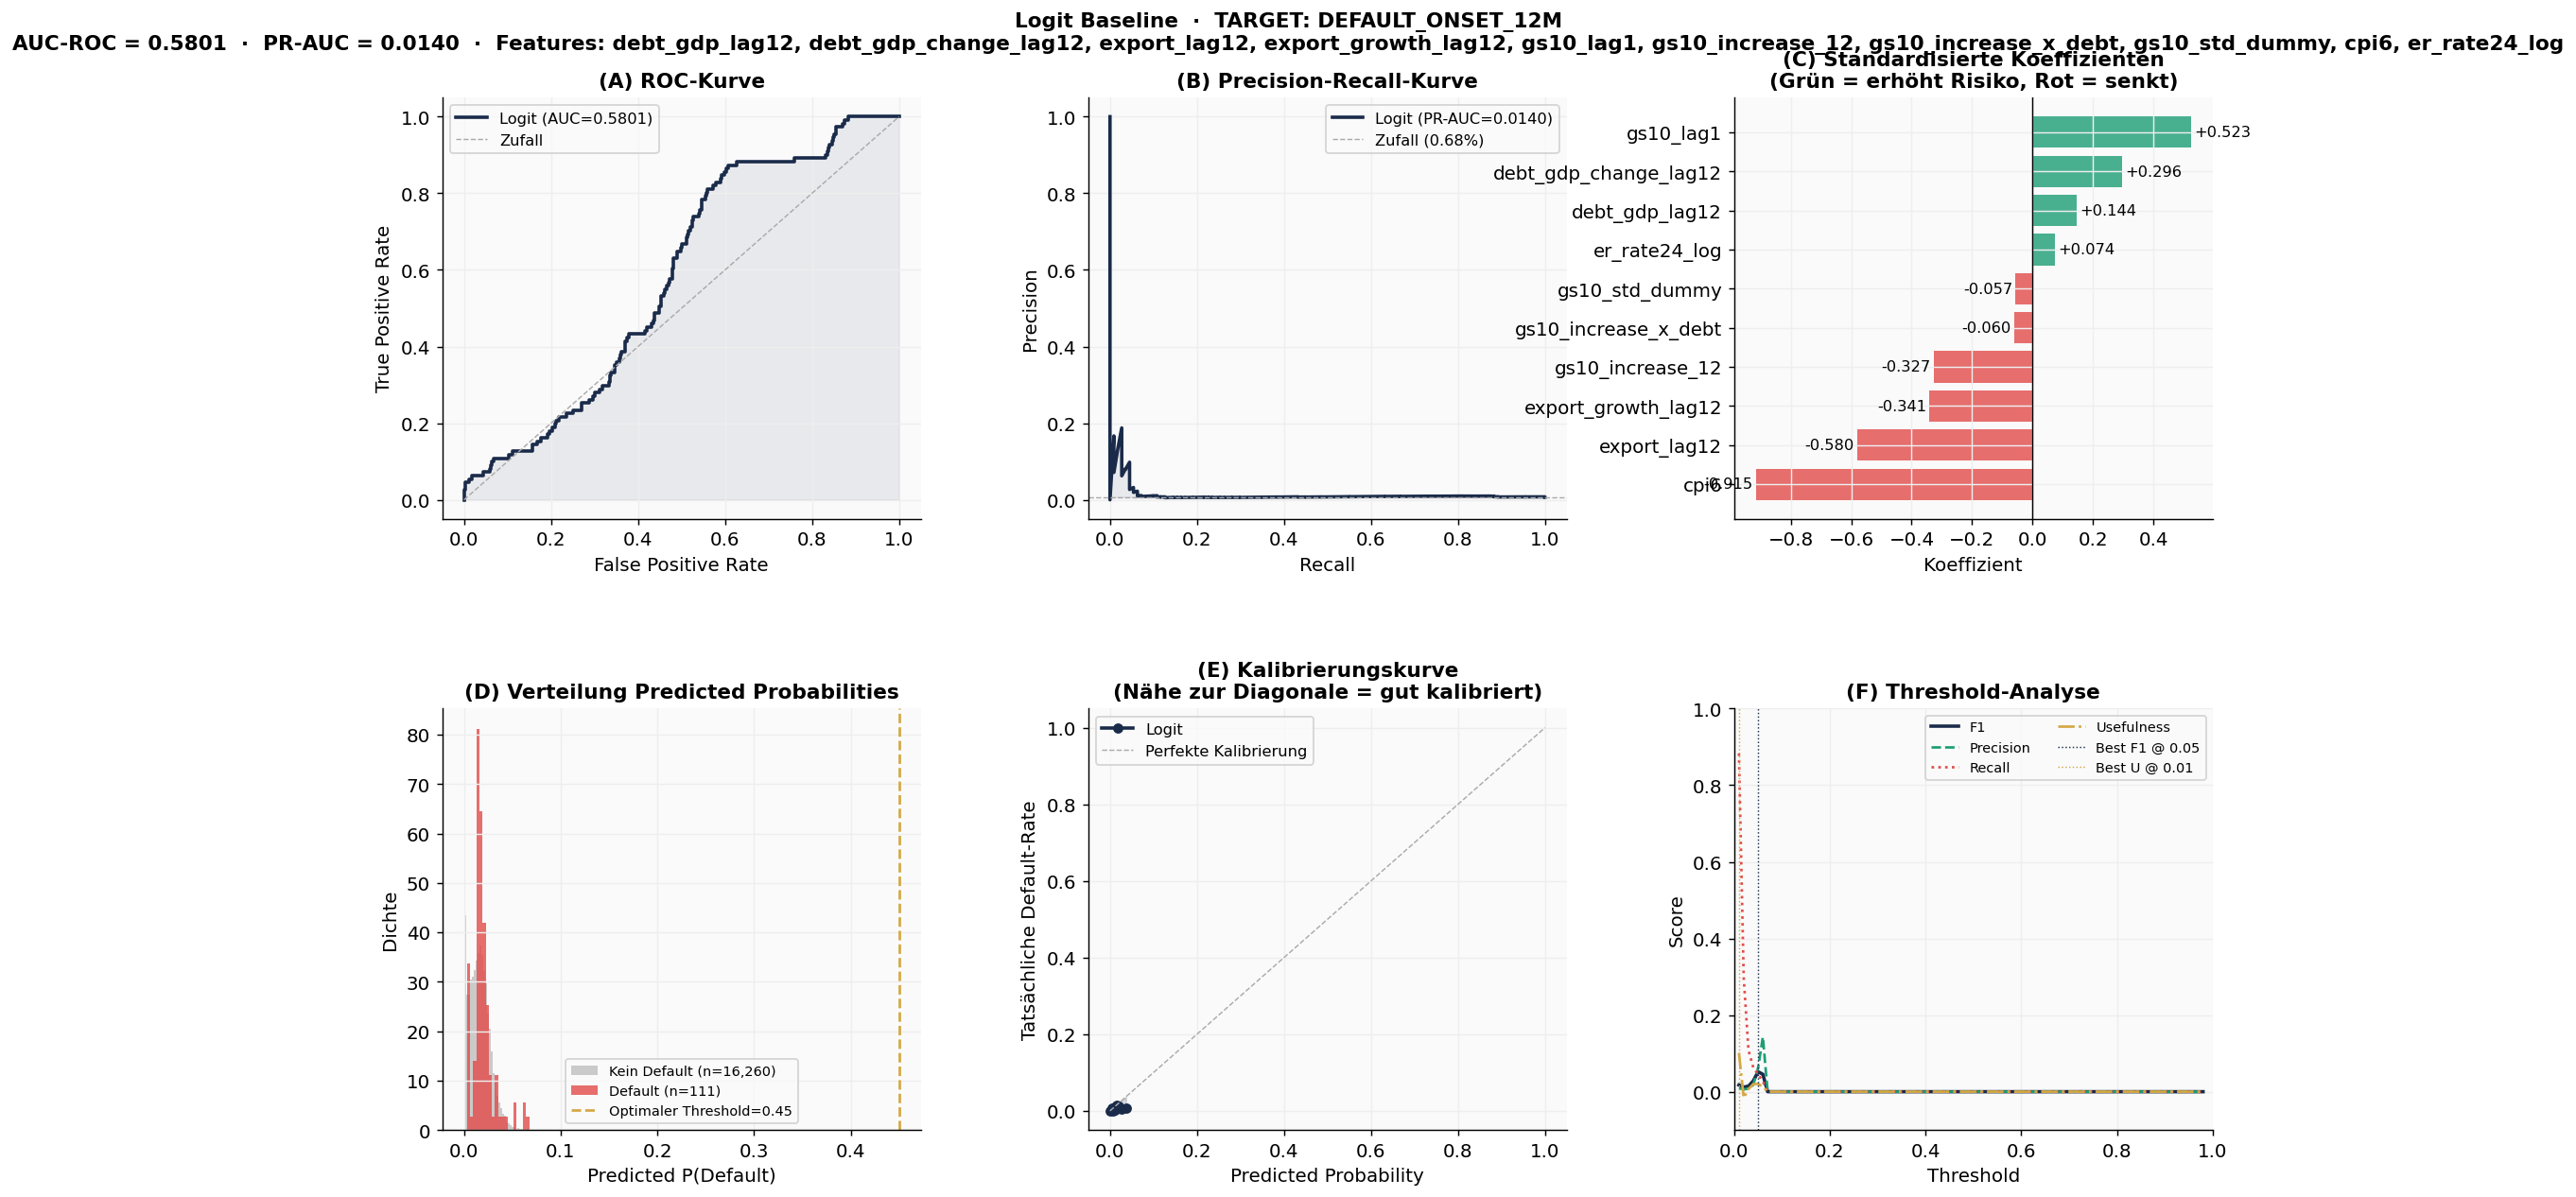


LOGIT ZUSAMMENFASSUNG
Features:     debt_gdp_lag12, debt_gdp_change_lag12, export_lag12, export_growth_lag12, gs10_lag1, gs10_increase_12, gs10_increase_x_debt, gs10_std_dummy, cpi6, er_rate24_log
AUC-ROC:      0.5801
PR-AUC:       0.0140

Optimaler Threshold:
  Nach F1:         0.05 (F1=0.052)
  Nach Usefulness: 0.01 (U=0.101)

Bei Threshold = 0.05:
  TP=5  FP=76  FN=106  TN=16184
  Precision: 0.062
  Recall:    0.045
  F1:        0.052
→ Diese Werte sind dein Benchmark für XGBoost.


In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# Logit Ergebnis-Visualisierung
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#FAFAFA",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#EEEEEE",
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "figure.dpi":        130,
})

C = {"logit": "#1A2B4A", "zero": "#AAAAAA",
     "pos": "#1D9E75", "neg": "#E24B4A", "gold": "#D4A843"}

fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    f"Logit Baseline  ·  TARGET: {FORECAST_TARGET}\n"
    f"AUC-ROC = {auc_roc_l:.4f}  ·  PR-AUC = {auc_pr_l:.4f}  ·  "
    f"Features: {', '.join(logit_features)}",
    fontsize=12, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(2, 3, figure=fig,
                       hspace=0.45, wspace=0.35,
                       left=0.07, right=0.97,
                       top=0.92, bottom=0.08)

# ── Panel A: ROC-Kurve ────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test_l, y_pred_logit)
ax.plot(fpr, tpr, color=C["logit"], lw=2,
        label=f'Logit (AUC={auc_roc_l:.4f})')
ax.plot([0,1],[0,1], color=C["zero"], lw=0.8, ls='--', label='Zufall')
ax.fill_between(fpr, tpr, alpha=0.08, color=C["logit"])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('(A) ROC-Kurve')
ax.legend(fontsize=9)

# ── Panel B: Precision-Recall-Kurve ──────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
prec, rec, _ = precision_recall_curve(y_test_l, y_pred_logit)
ax.plot(rec, prec, color=C["logit"], lw=2,
        label=f'Logit (PR-AUC={auc_pr_l:.4f})')
baseline_pr = y_test_l.mean()
ax.axhline(baseline_pr, color=C["zero"], lw=0.8, ls='--',
           label=f'Zufall ({baseline_pr:.2%})')
ax.fill_between(rec, prec, baseline_pr, alpha=0.08, color=C["logit"])
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('(B) Precision-Recall-Kurve')
ax.legend(fontsize=9)

# ── Panel C: Odds-Ratio-Plot ──────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])

# Koeffizienten aus sklearn-Modell (standardisiert)
coefs = pd.Series(
    logit_model.coef_[0],
    index=logit_features
).sort_values()

# Approximierte 95%-KI (aus Standardfehler der standardisierten Features)
# Für exakte KI: statsmodels verwenden
colors_bar = [C["pos"] if c > 0 else C["neg"] for c in coefs.values]
bars = ax.barh(coefs.index, coefs.values, color=colors_bar, alpha=0.8)

ax.axvline(0, color='black', lw=0.8)
for bar, val in zip(bars, coefs.values):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

ax.set_title('(C) Standardisierte Koeffizienten\n(Grün = erhöht Risiko, Rot = senkt)')
ax.set_xlabel('Koeffizient')

# ── Panel D: Predicted Probability Verteilung ─────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
mask_pos = y_test_l == 1
mask_neg = y_test_l == 0

ax.hist(y_pred_logit[mask_neg], bins=40, alpha=0.6,
        color=C["zero"], label=f'Kein Default (n={mask_neg.sum():,})',
        density=True)
ax.hist(y_pred_logit[mask_pos], bins=20, alpha=0.8,
        color=C["neg"], label=f'Default (n={mask_pos.sum():,})',
        density=True)
ax.axvline(0.45, color=C["gold"], lw=1.5, ls='--',
           label='Optimaler Threshold=0.45')
ax.set_xlabel('Predicted P(Default)')
ax.set_ylabel('Dichte')
ax.set_title('(D) Verteilung Predicted Probabilities')
ax.legend(fontsize=8)

# ── Panel E: Kalibrierungskurve ───────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
fraction_pos, mean_pred = calibration_curve(
    y_test_l, y_pred_logit, n_bins=10, strategy='quantile'
)
ax.plot(mean_pred, fraction_pos, color=C["logit"], lw=2,
        marker='o', ms=5, label='Logit')
ax.plot([0,1],[0,1], color=C["zero"], lw=0.8, ls='--',
        label='Perfekte Kalibrierung')
ax.fill_between(mean_pred,
                fraction_pos, mean_pred,
                alpha=0.15, color=C["logit"])
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Tatsächliche Default-Rate')
ax.set_title('(E) Kalibrierungskurve\n(Nähe zur Diagonale = gut kalibriert)')
ax.legend(fontsize=9)

# ── Panel F: Threshold-Analyse ────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])

thresholds = np.arange(0.01, 0.99, 0.01)
f1_scores, prec_scores, rec_scores, u_scores = [], [], [], []

for t in thresholds:
    yb = (y_pred_logit >= t).astype(int)
    tp = ((yb==1)&(y_test_l==1)).sum()
    fp = ((yb==1)&(y_test_l==0)).sum()
    tn = ((yb==0)&(y_test_l==0)).sum()
    fn = ((yb==0)&(y_test_l==1)).sum()

    p  = tp/(tp+fp) if (tp+fp)>0 else 0
    r  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1 = 2*p*r/(p+r) if (p+r)>0 else 0
    fpr_t = fp/(fp+tn) if (fp+tn)>0 else 0
    fnr_t = fn/(fn+tp) if (fn+tp)>0 else 0
    u  = min(0.5, 0.5) - (0.5*fnr_t + 0.5*fpr_t)

    f1_scores.append(f1)
    prec_scores.append(p)
    rec_scores.append(r)
    u_scores.append(u)

ax.plot(thresholds, f1_scores,   color=C["logit"], lw=2, label='F1')
ax.plot(thresholds, prec_scores, color=C["pos"],   lw=1.5, ls='--',
        label='Precision')
ax.plot(thresholds, rec_scores,  color=C["neg"],   lw=1.5, ls=':',
        label='Recall')
ax.plot(thresholds, u_scores,    color=C["gold"],  lw=1.5, ls='-.',
        label='Usefulness')

best_f1_idx = np.argmax(f1_scores)
best_u_idx  = np.argmax(u_scores)
ax.axvline(thresholds[best_f1_idx], color=C["logit"], lw=0.8, ls=':',
           label=f'Best F1 @ {thresholds[best_f1_idx]:.2f}')
ax.axvline(thresholds[best_u_idx],  color=C["gold"],  lw=0.8, ls=':',
           label=f'Best U @ {thresholds[best_u_idx]:.2f}')

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('(F) Threshold-Analyse')
ax.legend(fontsize=8, ncol=2)
ax.set_xlim(0, 1)
ax.set_ylim(-0.1, 1.0)

plt.savefig('logit_results.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# ── Numerische Zusammenfassung ────────────────────────────────────────────────
print(f"\n{'='*55}")
print("LOGIT ZUSAMMENFASSUNG")
print(f"{'='*55}")
print(f"Features:     {', '.join(logit_features)}")
print(f"AUC-ROC:      {auc_roc_l:.4f}")
print(f"PR-AUC:       {auc_pr_l:.4f}")
print(f"\nOptimaler Threshold:")
print(f"  Nach F1:         {thresholds[best_f1_idx]:.2f} "
      f"(F1={f1_scores[best_f1_idx]:.3f})")
print(f"  Nach Usefulness: {thresholds[best_u_idx]:.2f} "
      f"(U={u_scores[best_u_idx]:.3f})")
print(f"\nBei Threshold = {thresholds[best_f1_idx]:.2f}:")
t_opt = thresholds[best_f1_idx]
yb = (y_pred_logit >= t_opt).astype(int)
tp = int(((yb==1)&(y_test_l==1)).sum())
fp = int(((yb==1)&(y_test_l==0)).sum())
fn = int(((yb==0)&(y_test_l==1)).sum())
tn = int(((yb==0)&(y_test_l==0)).sum())
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"  Precision: {tp/(tp+fp) if (tp+fp)>0 else 0:.3f}")
print(f"  Recall:    {tp/(tp+fn) if (tp+fn)>0 else 0:.3f}")
print(f"  F1:        {f1_scores[best_f1_idx]:.3f}")
print(f"{'='*55}")
print("→ Diese Werte sind dein Benchmark für XGBoost.")

# Execution

In [32]:
# ── 1. Donor Pools (rollend pro Dekade) ──────────────────────────────────────
print("\n── Schritt 1: Rollende Donor Pools berechnen ───────────────")

all_donor_pools = build_donor_pools_rolling(
    df                 = analysis_df,
    matching_features  = MATCHING_FEATURES_RF,
    min_history_months = 48,
    decade_ends        = ["1984-12", "1994-12", "2004-12",
                          "2014-12", "2020-12"],
)

# Übersicht ausgeben
for decade, pools in all_donor_pools.items():
    n_with_pool = sum(1 for p in pools.values() if len(p) >= 2)
    print(f"  {decade}: {n_with_pool}/{len(pools)} Länder mit ≥2 Donor-Ländern")


── Schritt 1: Rollende Donor Pools berechnen ───────────────


  1984-12: 121/202 Länder mit ≥2 Donor-Ländern
  1994-12: 140/202 Länder mit ≥2 Donor-Ländern
  2004-12: 165/211 Länder mit ≥2 Donor-Ländern
  2014-12: 176/213 Länder mit ≥2 Donor-Ländern
  2020-12: 179/213 Länder mit ≥2 Donor-Ländern


In [33]:
#@title <b>Time Out Preventer (Advanced) </b></strong>
%%capture
AUTO_RECONNECT = True #@param {type:"boolean"}
#@markdown **Run this code to prevent Google Colab from Timeout**
from os import makedirs
makedirs("/root/.config/rclone", exist_ok = True)
if AUTO_RECONNECT:
  import IPython
  from google.colab import output

  display(IPython.display.Javascript('''
  function ClickConnect(){
    btn = document.querySelector("colab-connect-button")
    if (btn != null){
      console.log("Click colab-connect-button");
      btn.click()
      }

    btn = document.getElementById('ok')
    if (btn != null){
      console.log("Click reconnect");
      btn.click()
      }
    }

  setInterval(ClickConnect,60000)
  '''))

# Rolling residuals

In [34]:
# ── 2. Rolling Residuen ───────────────────────────────────────────────────────
print("\n── Schritt 2: Rolling SC Residuen ──────────────────────────")

# Länder-Reihenfolge: Default-Länder zuerst
default_countries_ordered = (
    analysis_df[analysis_df['DEFAULT'] == 1]['COUNTRY']
    .unique().tolist()
)
last_decade   = sorted(all_donor_pools.keys())[-1]
all_countries = list(all_donor_pools[last_decade].keys())

non_default_countries = [
    c for c in all_countries
    if c not in default_countries_ordered
]
priority_order = default_countries_ordered + non_default_countries

import os
#CACHE_PATH = 'residuals_cache_12M_Onset.csv'
CACHE_PATH = 'residuals_cache_12M_Onset_logit_pred.csv'

if os.path.exists(CACHE_PATH):
    print(f"Cache gefunden – lade Residuen...")
    residuals_df = pd.read_csv(CACHE_PATH, parse_dates=['TIME'])
    print(f"Geladen: {len(residuals_df):,} Zeilen, "
          f"{residuals_df['COUNTRY'].nunique()} Länder")
else:
    print("Kein Cache – berechne Residuen neu ...")
    residuals_df = compute_all_residuals(
        df              = analysis_df,
        all_donor_pools = all_donor_pools,
        residual_vars   = RESIDUAL_VARS,
        window          = ROLLING_WINDOW,
        max_countries   = None,
    )
    if not residuals_df.empty:
        residuals_df.to_csv(CACHE_PATH, index=False)
        print(f"Cache gespeichert: {CACHE_PATH}")

# ── SC-Distanz Features berechnen (einmalig) ─────────────────────────────────
if not residuals_df.empty and 'sc_distance' in residuals_df.columns:
    residuals_df = residuals_df.sort_values(['COUNTRY', 'TIME'])

    for lag in [1, 3, 6]:
        residuals_df[f'sc_distance_lag{lag}'] = (
            residuals_df.groupby('COUNTRY')['sc_distance']
            .shift(lag)
        )

    residuals_df['sc_distance_accel'] = (
        residuals_df.groupby('COUNTRY')['sc_distance']
        .diff(3)
    )

    residuals_df['sc_distance_max6'] = (
        residuals_df.groupby('COUNTRY')['sc_distance']
        .transform(lambda x: x.rolling(6, min_periods=2).max())
    )

    residuals_df['sc_distance_max6_pctrank'] = (
        residuals_df.groupby('COUNTRY')['sc_distance_max6']
        .transform(lambda x: x.rank(pct=True))
    )

    residuals_df['sc_distance_max6_pctrank_36m'] = (
        residuals_df.groupby('COUNTRY')['sc_distance_max6']
        .transform(lambda x:
            x.rolling(36, min_periods=12)
             .apply(lambda w: pd.Series(w).rank(pct=True).iloc[-1],
                    raw=False)
        )
    )

    residuals_df['sc_distance_zscore'] = (
        residuals_df.groupby('COUNTRY')['sc_distance']
        .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
    )

    residuals_df['sc_distance_pctrank'] = (
        residuals_df.groupby('COUNTRY')['sc_distance']
        .transform(lambda x: x.rank(pct=True))
    )

    residuals_df['sc_distance_pctrank_36m'] = (
        residuals_df.groupby('COUNTRY')['sc_distance']
        .transform(lambda x:
            x.rolling(36, min_periods=12)
             .apply(lambda w: pd.Series(w).rank(pct=True).iloc[-1],
                    raw=False)
        )
    )

    residuals_df = residuals_df.replace([np.inf, -np.inf], np.nan)

    sc_cols = [c for c in residuals_df.columns if 'sc_distance' in c]
    print("\nSC-Distanz Features:")
    for col in sc_cols:
        coverage = residuals_df[col].notna().mean()
        print(f"  {col:<40} Abdeckung: {coverage:.1%}")

if residuals_df.empty:
    print("Keine Residuen berechnet. Prüfe Datenverfügbarkeit.")
else:
    print(f"\nResidualspalten: "
          f"{[c for c in residuals_df.columns if c not in ['TIME', 'COUNTRY']]}")



── Schritt 2: Rolling SC Residuen ──────────────────────────
Cache gefunden – lade Residuen...
Geladen: 79,576 Zeilen, 175 Länder

SC-Distanz Features:
  sc_distance                              Abdeckung: 99.0%
  sc_distance_ma3                          Abdeckung: 99.0%
  sc_distance_ma6                          Abdeckung: 98.8%
  sc_distance_change                       Abdeckung: 98.3%
  sc_distance_lag1                         Abdeckung: 98.8%
  sc_distance_lag3                         Abdeckung: 98.3%
  sc_distance_lag6                         Abdeckung: 97.7%
  sc_distance_accel                        Abdeckung: 98.3%
  sc_distance_max6                         Abdeckung: 98.8%
  sc_distance_max6_pctrank                 Abdeckung: 98.8%
  sc_distance_max6_pctrank_36m             Abdeckung: 96.3%
  sc_distance_zscore                       Abdeckung: 99.0%
  sc_distance_pctrank                      Abdeckung: 99.0%
  sc_distance_pctrank_36m                  Abdeckung: 96.6%

Residu

In [63]:
# ── 3. Feature-Matrix ─────────────────────────────────────────────────────────
print("\n── Schritt 3: Feature-Matrix bauen ─────────────────────────")

feature_df = build_feature_matrix(
    df               = analysis_df_train,   # ← bereinigt: keine laufenden Defaults
    residuals_df     = residuals_df,
    forecast_horizon = FORECAST_HORIZON,
    target_col       = FORECAST_TARGET,
)


print(f"Feature-Matrix: {feature_df.shape}")


── Schritt 3: Feature-Matrix bauen ─────────────────────────
Target 'DEFAULT_ONSET_12M': 2,118 positive Monate (1.967%)
Feature-Matrix: (107673, 97)


In [64]:
# ── inf-Werte bereinigen vor XGBoost ─────────────────────────────────────────
print("\nPrüfe auf inf-Werte...")
inf_cols = [
    c for c in feature_df.select_dtypes(include=[np.number]).columns
    if np.isinf(feature_df[c]).any()
]
print(f"Spalten mit inf-Werten: {inf_cols}")
for c in inf_cols:
    n = np.isinf(feature_df[c]).sum()
    print(f"  {c}: {n} inf-Werte")

feature_df = feature_df.replace([np.inf, -np.inf], np.nan)

# ── Leakage-Spalten aus feature_df entfernen ─────────────────────────────────
LEAKAGE_COLS = [
    'DEFAULT_ONSET_24M',
    'End of restructuring: completion of exchange',
    'Start of default or restructuring process: default or announcement',
    'DEFAULT',
    'DEFAULT_ONSET',
    #'DEFAULT_DB',
    # 'DEFAULT_ONSET_12M' → NICHT hier: das ist das Target, muss bleiben
    # 'DEFAULT' → wird in plot_results für Panel D gebraucht
    #             deshalb aus feature_df entfernen aber in analysis_df behalten
]

leakage_found = [c for c in LEAKAGE_COLS if c in feature_df.columns]

if leakage_found:
    feature_df = feature_df.drop(columns=leakage_found)
    print(f"✓ Entfernt aus feature_df: {leakage_found}")
else:
    print("✓ Keine Leakage-Spalten in feature_df gefunden")

print(f"feature_df Shape nach Bereinigung: {feature_df.shape}")

# Sicherheitscheck: Target muss noch da sein
assert FORECAST_TARGET in feature_df.columns, \
    f"FEHLER: Target '{FORECAST_TARGET}' wurde versehentlich entfernt!"
print(f"✓ Target '{FORECAST_TARGET}' vorhanden: "
      f"{feature_df[FORECAST_TARGET].sum():,} positive Monate")

remaining = [
    c for c in feature_df.select_dtypes(include=[np.number]).columns
    if np.isinf(feature_df[c]).any()
]
print(f"Verbleibende inf-Werte nach Bereinigung: {len(remaining)} Spalten")


Prüfe auf inf-Werte...
Spalten mit inf-Werten: []
✓ Entfernt aus feature_df: ['DEFAULT_ONSET_24M', 'End of restructuring: completion of exchange', 'Start of default or restructuring process: default or announcement', 'DEFAULT', 'DEFAULT_ONSET']
feature_df Shape nach Bereinigung: (107673, 92)
✓ Target 'DEFAULT_ONSET_12M' vorhanden: 2,118 positive Monate
Verbleibende inf-Werte nach Bereinigung: 0 Spalten



── Schritt 4: XGBoost trainieren ───────────────────────────
── Leakage-Check ─────────────────────────────────────────────
✓ Keine Leakage-Spalten in feature_df
✓ Keine Leakage in residual_features
✓ Keine Leakage in macro_features
✓ Keine Features mit verdächtiger Korrelation zum Target
Onset-Rate Train:   2.42% → scale_pos_weight: 40.2
Train: ✓ keine inf-Werte (691673 NaN → XGBoost verarbeitet nativ)
Val: ✓ keine inf-Werte (81210 NaN → XGBoost verarbeitet nativ)
Test: ✓ keine inf-Werte (104002 NaN → XGBoost verarbeitet nativ)
  AUC-ROC  unkalibriert: 0.6995  kalibriert: 0.6997
  PR-AUC   unkalibriert: 0.0137  kalibriert: 0.0116


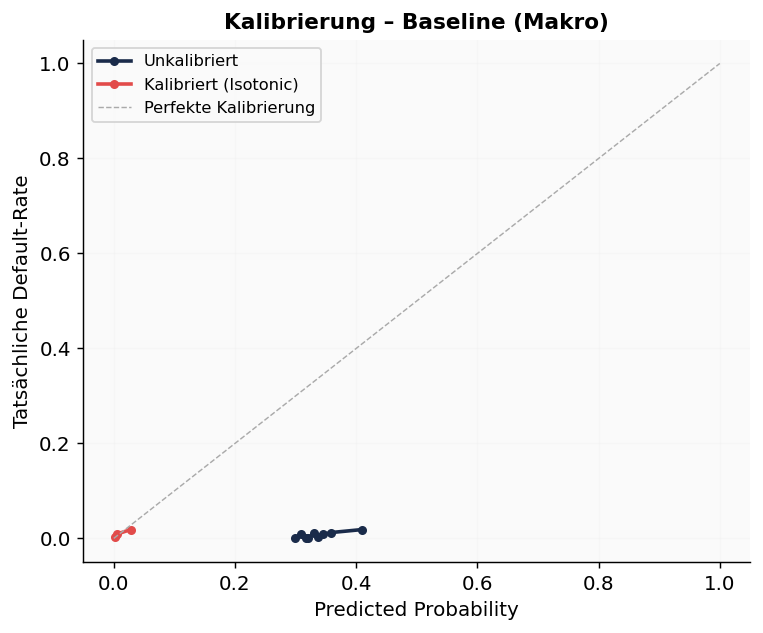

Train: ✓ keine inf-Werte (691673 NaN → XGBoost verarbeitet nativ)
Val: ✓ keine inf-Werte (81210 NaN → XGBoost verarbeitet nativ)
Test: ✓ keine inf-Werte (104002 NaN → XGBoost verarbeitet nativ)
  AUC-ROC  unkalibriert: 0.7123  kalibriert: 0.7015
  PR-AUC   unkalibriert: 0.0128  kalibriert: 0.0117


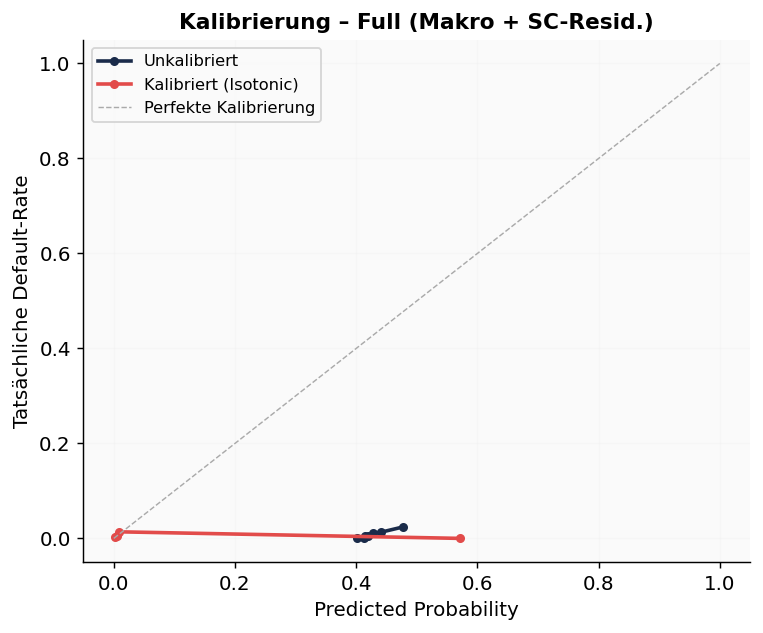


Länder mit Onset im Testset (2011-01–2020):
  11 von 213 Ländern
['Argentina', 'Barbados', 'Belize', 'Chad', 'Ecuador', 'Greece', 'Grenada', 'Mongolia', 'Mozambique, Republic of', 'St. Kitts and Nevis', 'Ukraine']


In [65]:
# ── 4. XGBoost ────────────────────────────────────────────────────────────────
print("\n── Schritt 4: XGBoost trainieren ───────────────────────────")

results = train_xgboost(
    feature_df       = feature_df,
    forecast_horizon = FORECAST_HORIZON,
    train_end        = TRAIN_END,
    gap_end          = GAP_END,
    test_start       = TEST_START,
    target_col       = FORECAST_TARGET,
)

# Testset-Zusammensetzung prüfen
test_mask = feature_df['TIME'] >= TEST_START
test_summary = (
    feature_df[test_mask]
    .groupby('COUNTRY')[FORECAST_TARGET]
    .max()
    .reset_index()
)
defaulting_in_test = test_summary[test_summary[FORECAST_TARGET] == 1]
print(f"\nLänder mit Onset im Testset ({TEST_START}–2020):")
print(f"  {len(defaulting_in_test)} von {len(test_summary)} Ländern")
print(defaulting_in_test['COUNTRY'].tolist())



── Schritt 5: Ergebnisse visualisieren ─────────────────────


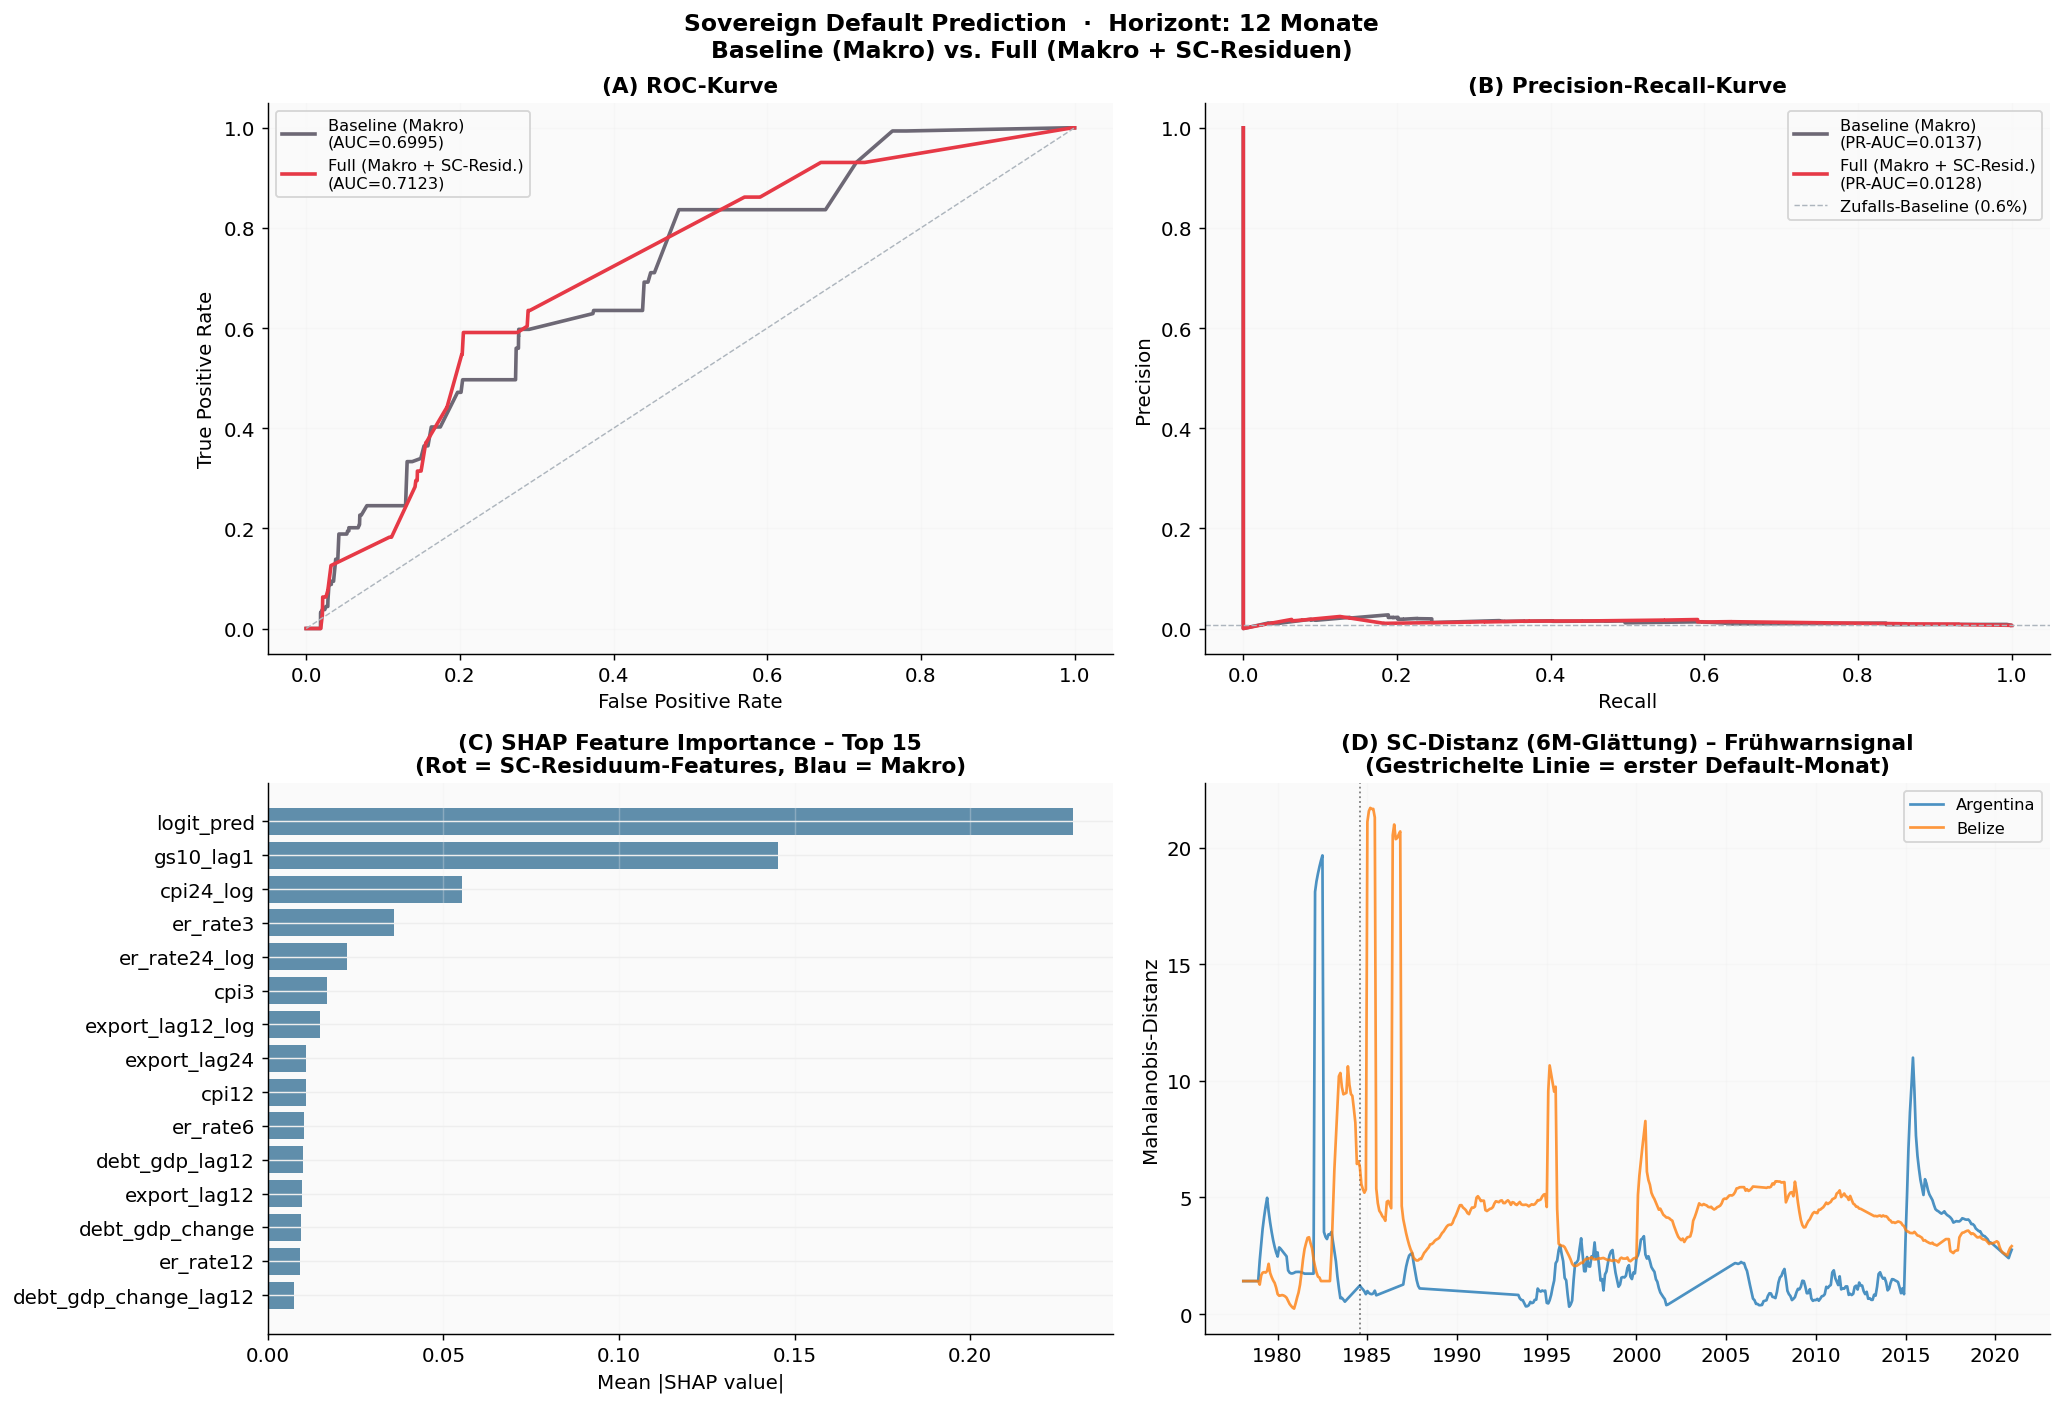


MEHRWERT DER SC-RESIDUEN:
  AUC-ROC:  0.6995 → 0.7123  (+0.0128)
  PR-AUC:   0.0137 → 0.0128  (-0.0010)

  Interpretation:
  ✓ SC-Residuen verbessern die Vorhersage messbar.
    Die Abweichung vom kontrafaktischen Pfad ist ein
    informatives Frühwarnsignal für Sovereign Defaults.


In [38]:
# ── 5. Visualisierung ─────────────────────────────────────────────────────────
print("\n── Schritt 5: Ergebnisse visualisieren ─────────────────────")
plot_results(results, feature_df, FORECAST_HORIZON)

In [66]:
# Prüfe zuerst was family_selected aktuell enthält:
print("family_selected:")
print(family_selected)

family_selected:
['debt_gdp_lag12', 'debt_gdp_change_lag12', 'export_lag12', 'export_growth_lag12', 'gs10_lag1', 'gs10_increase_12', 'gs10_increase_x_debt', 'gs10_std_dummy', 'cpi6', 'er_rate24_log']


In [39]:
##### Test after execution - delete afterwards #####
# Prüfe ob logit_model nur auf Training gefittet wurde
print("Logit Training-Zeitraum:")
print(f"  train_l TIME: {train_l['TIME'].min()} – {train_l['TIME'].max()}")
print(f"  TRAIN_END:    {TRAIN_END}")
print(f"  Überschneidung mit Test: "
      f"{(train_l['TIME'] >= TEST_START).sum()} Zeilen")

# Prüfe logit_pred Verteilung im Testset
test_mask_feat = feature_df['TIME'] >= TEST_START
print(f"\nlogit_pred im Testset:")
print(f"  Mean: {feature_df.loc[test_mask_feat, 'logit_pred'].mean():.4f}")
print(f"  Std:  {feature_df.loc[test_mask_feat, 'logit_pred'].std():.4f}")
print(f"  Max:  {feature_df.loc[test_mask_feat, 'logit_pred'].max():.4f}")

# Korrelation von logit_pred mit Target im Test
corr = feature_df.loc[test_mask_feat, ['logit_pred', FORECAST_TARGET]].corr()
print(f"\nKorrelation logit_pred ↔ {FORECAST_TARGET} im Test:")
print(f"  {corr.loc['logit_pred', FORECAST_TARGET]:.4f}")

# Korrelation im Training
train_mask_feat = feature_df['TIME'] <= TRAIN_END
corr_train = feature_df.loc[train_mask_feat, ['logit_pred', FORECAST_TARGET]].corr()
print(f"\nKorrelation logit_pred ↔ {FORECAST_TARGET} im Training:")
print(f"  {corr_train.loc['logit_pred', FORECAST_TARGET]:.4f}")

Logit Training-Zeitraum:
  train_l TIME: 1977-02-01 00:00:00 – 2009-12-01 00:00:00
  TRAIN_END:    2009-12
  Überschneidung mit Test: 0 Zeilen

logit_pred im Testset:
  Mean: 0.0300
  Std:  0.0353
  Max:  0.4918

Korrelation logit_pred ↔ DEFAULT_ONSET_12M im Test:
  0.0411

Korrelation logit_pred ↔ DEFAULT_ONSET_12M im Training:
  0.1969


In [69]:
# Aus dem Full-Modell SHAP-Werte extrahieren
full_key  = [k for k in results if 'Full' in k][0]
full_res  = results[full_key]

explainer   = shap.TreeExplainer(full_res['model'])
shap_values = explainer.shap_values(full_res['X_test'])

shap_df = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=full_res['features']
).sort_values(ascending=False)

print("Top 10 SHAP Features:")
print(shap_df.head(10).round(4).to_string())

# Anteil von logit_pred am gesamten SHAP
total_shap   = shap_df.sum()
logit_val    = shap_df.get('logit_pred', 0)
logit_share  = logit_val / total_shap if total_shap > 0 else 0
print(f"Anteil logit_pred am SHAP gesamt: {logit_share:.1%}")
print(f"  logit_pred SHAP absolut: {logit_val:.4f}")
print(f"  Gesamt SHAP:             {total_shap:.4f}")

Top 10 SHAP Features:
logit_pred          0.2292
gs10_lag1           0.1453
cpi24_log           0.0553
er_rate3            0.0359
er_rate24_log       0.0227
cpi3                0.0168
export_lag12_log    0.0148
export_lag24        0.0110
cpi12               0.0110
er_rate6            0.0104
Anteil logit_pred am SHAP gesamt: 36.1%
  logit_pred SHAP absolut: 0.2292
  Gesamt SHAP:             0.6351


In [ ]:
################################################################

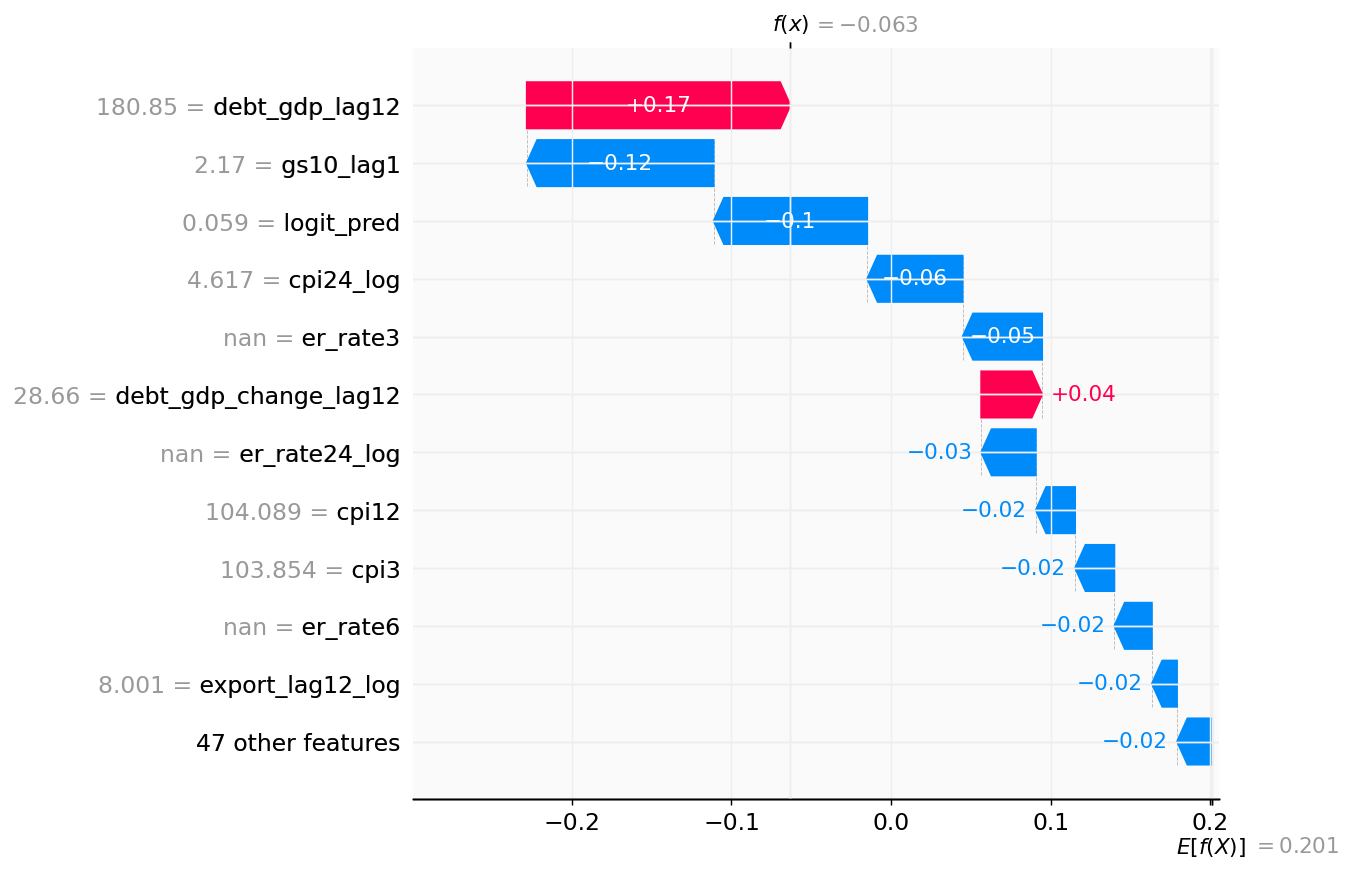

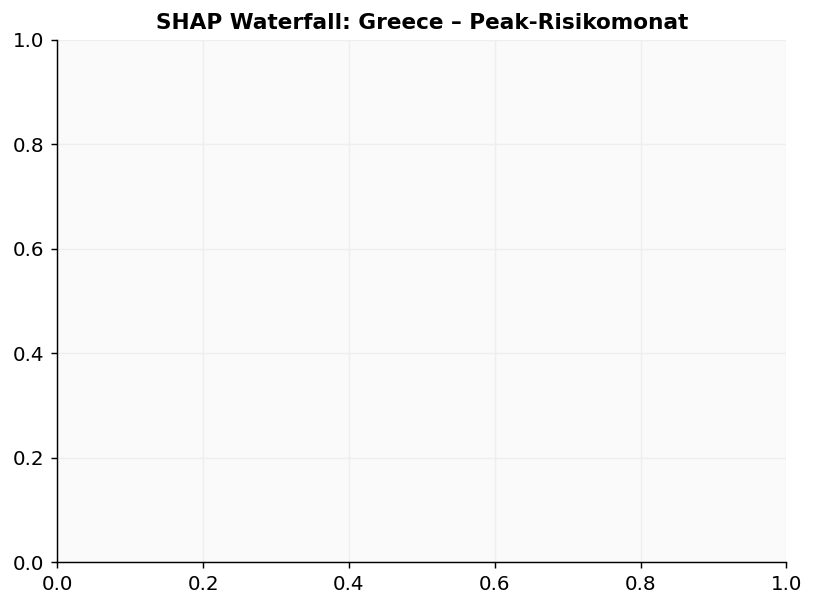

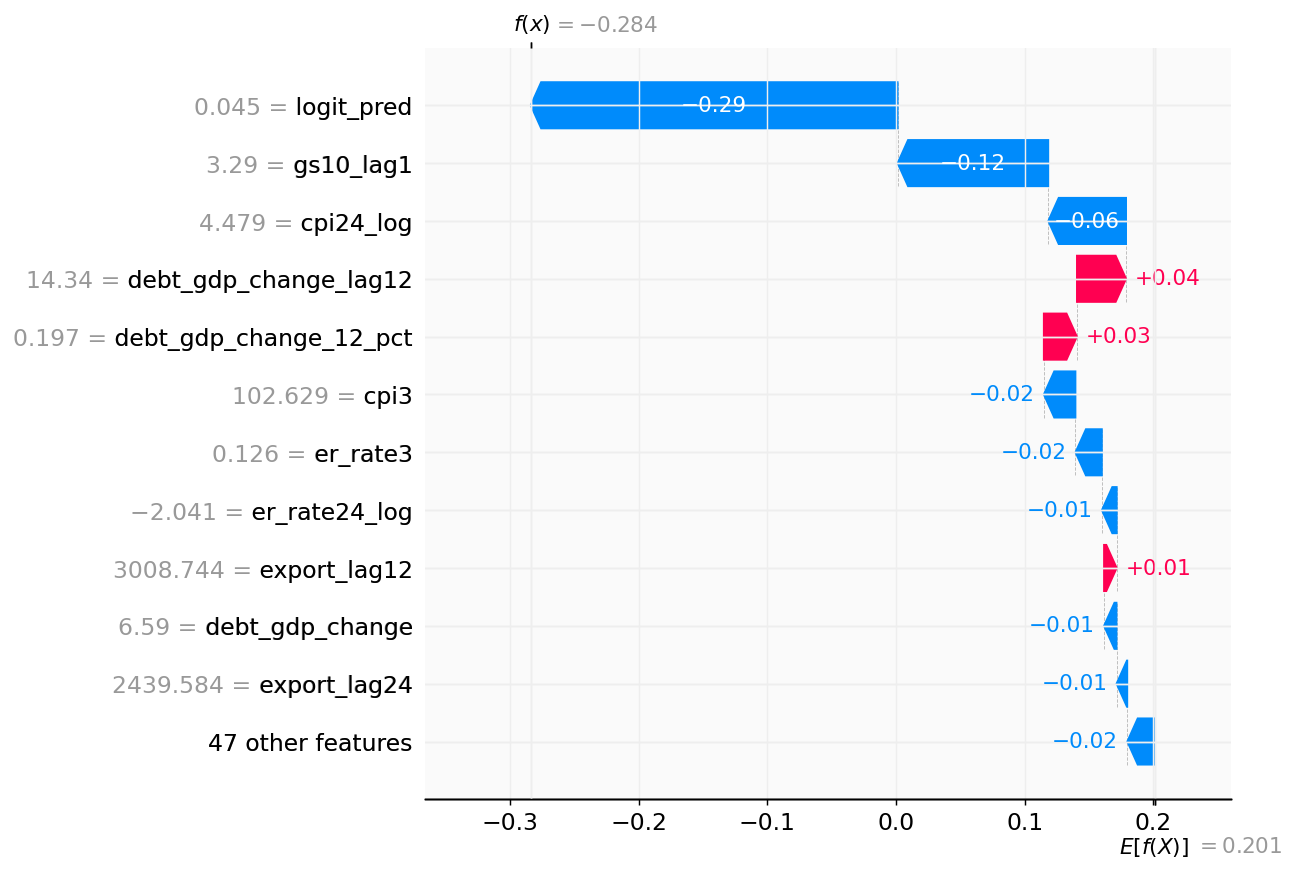

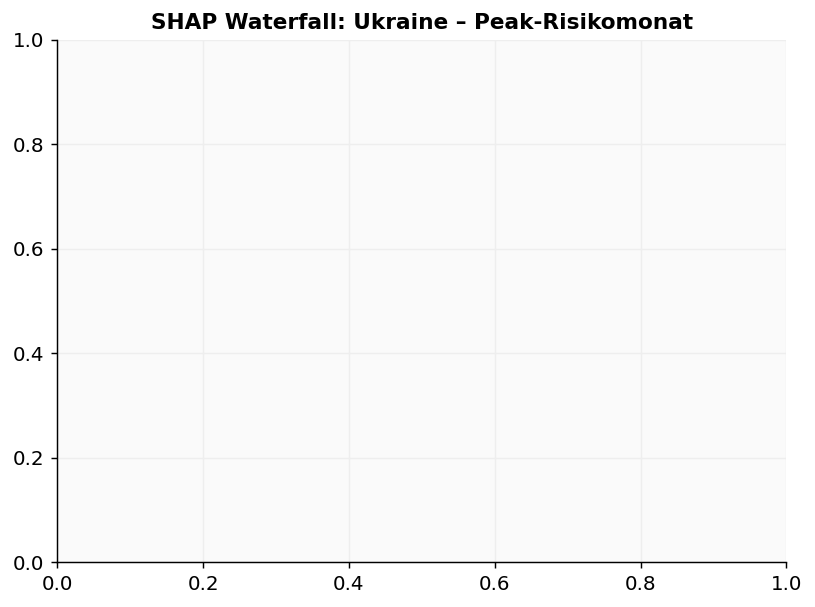

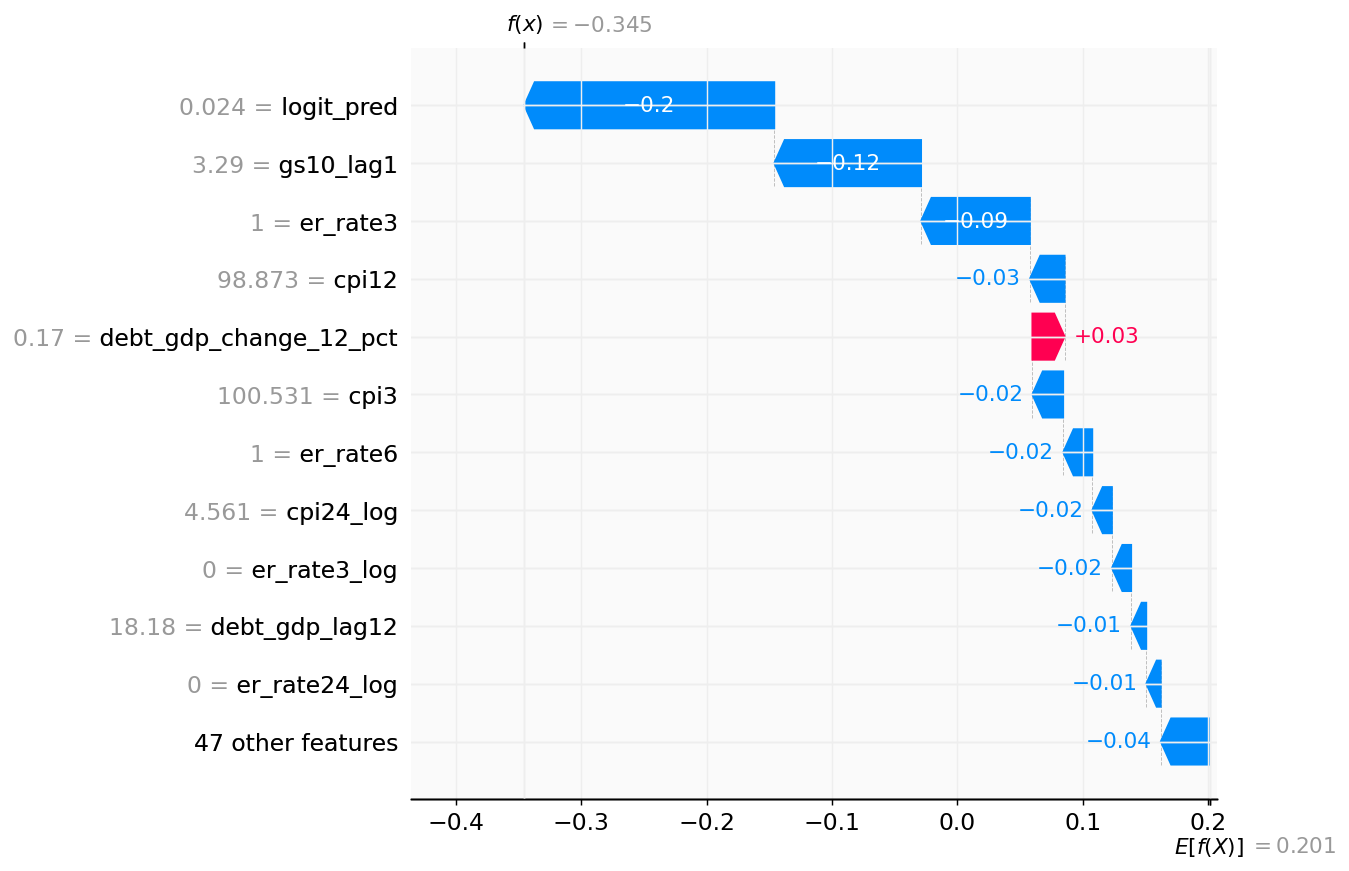

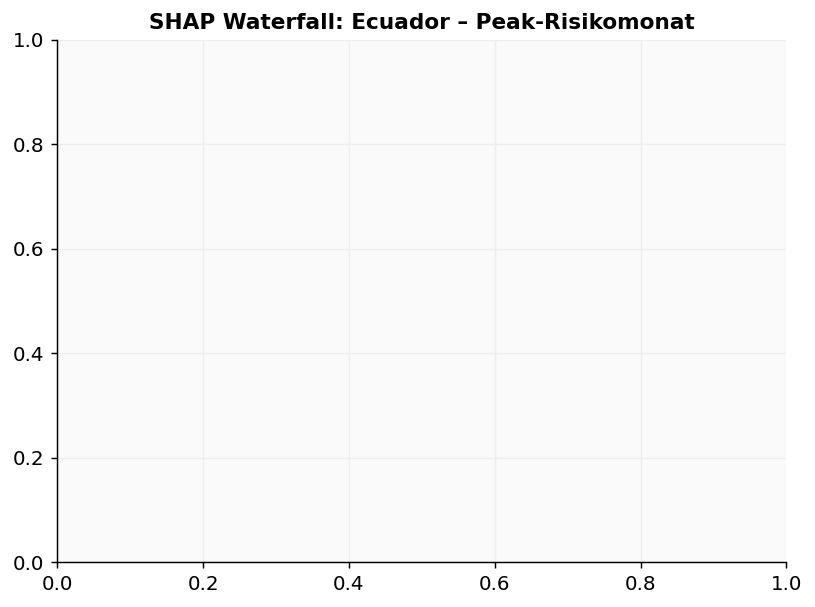

In [41]:
# ── SHAP Länderanalyse ───────────────────────────────────────
full_key = [k for k in results if 'Full' in k][0]
full_res  = results[full_key]
explainer = shap.TreeExplainer(full_res["model"])

# Für ausgewählte Länder (Default im Testset)
for country in ['Greece', 'Ukraine', 'Ecuador']:
    mask = feature_df['COUNTRY'] == country
    mask_test = mask & (feature_df['TIME'] >= TEST_START)

    if mask_test.sum() == 0:
        continue

    X_country = full_res['X_test'].loc[
        full_res['X_test'].index.isin(
            feature_df[mask_test].index
        )
    ]
    if len(X_country) == 0:
        continue

    shap_vals = explainer.shap_values(X_country)

    # Monat mit höchster Predicted Probability
    country_preds = full_res['y_pred'][
        [i for i, idx in enumerate(full_res['X_test'].index)
         if idx in X_country.index]
    ]
    peak_idx = np.argmax(country_preds)

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals[peak_idx],
            base_values=explainer.expected_value,
            data=X_country.iloc[peak_idx],
            feature_names=full_res['features']
        ),
        max_display=12
    )
    plt.title(f"SHAP Waterfall: {country} – Peak-Risikomonat")
    plt.tight_layout()
    plt.show()

## Diagnostic

In [42]:
print("── Diagnose 1: Temporal Leakage Check ──────────────────────")

# Features die potentiell Leakage enthalten
suspicious = []
for col in feature_df.columns:
    if col in [FORECAST_TARGET, 'DEFAULT', 'DEFAULT_DB',
                'DEFAULT_ONSET', 'TIME', 'COUNTRY']:
        continue
    # Korrelation zwischen Feature und Target im GLEICHEN Monat
    valid = feature_df[[col, FORECAST_TARGET]].dropna()
    if len(valid) < 100:
        continue
    corr = valid[col].corr(valid[FORECAST_TARGET])
    if abs(corr) > 0.5:   # Schwellenwert: hohe Korrelation verdächtig
        suspicious.append({'Feature': col, 'Korrelation': round(corr, 4)})

suspicious_df = pd.DataFrame(suspicious)
if len(suspicious_df) > 0:
    suspicious_df = suspicious_df.sort_values(
        'Korrelation', key=abs, ascending=False
    )
    print(f"\n⚠ Verdächtige Features (|Korr| > 0.5):")
    print(suspicious_df.to_string(index=False))
else:
    print("✓ Kein offensichtliches Leakage gefunden")

── Diagnose 1: Temporal Leakage Check ──────────────────────
✓ Kein offensichtliches Leakage gefunden


In [43]:
# ══════════════════════════════════════════════════════════════════════════════
# DIAGNOSE 2: Train/Test Distribution Check (Fuertes & Kalotychou 2007)
# Prüft ob Train und Test aus der gleichen Verteilung kommen
# ══════════════════════════════════════════════════════════════════════════════

from scipy import stats

print("── Diagnose 2: Train/Test Verteilungscheck ─────────────────")

train_mask = feature_df['TIME'] <= TRAIN_END
test_mask  = feature_df['TIME'] >= TEST_START

key_features = ['gs10_12', 'debt_gdp_lag12', 'export_lag12',
                'cpi3', 'er_rate3', FORECAST_TARGET]
key_features = [f for f in key_features if f in feature_df.columns]

print(f"\n{'Feature':<30} {'Train Mean':>11} {'Test Mean':>10} "
      f"{'Train Std':>10} {'Test Std':>9} {'KS p-val':>9}")
print("─" * 85)

for col in key_features:
    tr = feature_df.loc[train_mask, col].dropna()
    te = feature_df.loc[test_mask,  col].dropna()
    if len(tr) < 10 or len(te) < 10:
        continue
    ks_stat, ks_pval = stats.ks_2samp(tr, te)
    flag = " ⚠" if ks_pval < 0.05 else "  ✓"
    print(f"{col:<30} {tr.mean():>11.3f} {te.mean():>10.3f} "
          f"{tr.std():>10.3f} {te.std():>9.3f} "
          f"{ks_pval:>9.4f}{flag}")

print("\nKS p-val < 0.05 → signifikant unterschiedliche Verteilung")
print("(erwartet für makroökonomische Variablen über Zeit)")

── Diagnose 2: Train/Test Verteilungscheck ─────────────────

Feature                         Train Mean  Test Mean  Train Std  Test Std  KS p-val
─────────────────────────────────────────────────────────────────────────────────────
gs10_12                              7.389      2.405      2.720     0.548    0.0000 ⚠
debt_gdp_lag12                      49.424     48.882     48.351    35.835    0.0000 ⚠
export_lag12                   7075224.046 27106864.217 113420150.214 399977960.352    0.0000 ⚠
cpi3                                50.813    127.855     30.955    35.266    0.0000 ⚠
er_rate3                         91184.887      0.300 810744.012     0.501    0.0000 ⚠
DEFAULT_ONSET_12M                    0.024      0.006      0.154     0.079    0.0000 ⚠

KS p-val < 0.05 → signifikant unterschiedliche Verteilung
(erwartet für makroökonomische Variablen über Zeit)


In [44]:
# ══════════════════════════════════════════════════════════════════════════════
# DIAGNOSE 3: Usefulness Score (Alessi & Detken 2011)
# Standardmetrik für Early Warning Systems in der Literatur
# Berücksichtigt unterschiedliche Kosten von Typ-I und Typ-II Fehlern
# ══════════════════════════════════════════════════════════════════════════════

print("── Diagnose 3: Usefulness Score (Alessi & Detken 2011) ─────")

full_key = [k for k in results if 'Full' in k][0]
y_true   = results[full_key]['y_test'].values
y_pred   = results[full_key]['y_pred']

# Usefulness = min(μ, 1-μ) - Loss
# μ = Präferenzparameter des Policymakers (0.5 = symmetrisch)
# Loss = μ × FNR + (1-μ) × FPR

print(f"\n{'Threshold':>10} {'FPR':>7} {'FNR':>7} "
      f"{'U(0.5)':>8} {'U(0.3)':>8} {'U(0.7)':>8}")
print("─" * 55)

best_u, best_thresh = -np.inf, 0.3

for thresh in np.arange(0.05, 0.95, 0.05):
    y_bin = (y_pred >= thresh).astype(int)
    tp = ((y_bin==1)&(y_true==1)).sum()
    fp = ((y_bin==1)&(y_true==0)).sum()
    tn = ((y_bin==0)&(y_true==0)).sum()
    fn = ((y_bin==0)&(y_true==1)).sum()

    fpr = fp/(fp+tn) if (fp+tn)>0 else 0
    fnr = fn/(fn+tp) if (fn+tp)>0 else 0

    def usefulness(mu):
        loss = mu * fnr + (1-mu) * fpr
        return min(mu, 1-mu) - loss

    u05 = usefulness(0.5)
    u03 = usefulness(0.3)   # Policymaker gewichtet FN stärker
    u07 = usefulness(0.7)   # Investor gewichtet FP stärker

    if u05 > best_u:
        best_u, best_thresh = u05, thresh

    print(f"{thresh:>10.2f} {fpr:>7.3f} {fnr:>7.3f} "
          f"{u05:>8.4f} {u03:>8.4f} {u07:>8.4f}")

print(f"\nOptimaler Threshold (U@0.5): {best_thresh:.2f} → U = {best_u:.4f}")
print("Positiver U-Score = Modell besser als 'nie warnen' oder 'immer warnen'")

── Diagnose 3: Usefulness Score (Alessi & Detken 2011) ─────

 Threshold     FPR     FNR   U(0.5)   U(0.3)   U(0.7)
───────────────────────────────────────────────────────
      0.05   1.000   0.000   0.0000  -0.4000   0.0000
      0.10   1.000   0.000   0.0000  -0.4000   0.0000
      0.15   1.000   0.000   0.0000  -0.4000   0.0000
      0.20   1.000   0.000   0.0000  -0.4000   0.0000
      0.25   1.000   0.000   0.0000  -0.4000   0.0000
      0.30   1.000   0.000   0.0000  -0.4000   0.0000
      0.35   1.000   0.000   0.0000  -0.4000   0.0000
      0.40   0.997   0.000   0.0016  -0.3978   0.0009
      0.45   0.025   0.937   0.0188   0.0012  -0.3636
      0.50   0.005   1.000  -0.0026  -0.0037  -0.4016
      0.55   0.002   1.000  -0.0010  -0.0014  -0.4006
      0.60   0.000   1.000  -0.0002  -0.0002  -0.4001
      0.65   0.000   1.000   0.0000   0.0000  -0.4000
      0.70   0.000   1.000   0.0000   0.0000  -0.4000
      0.75   0.000   1.000   0.0000   0.0000  -0.4000
      0.80   0.000

In [45]:
# ══════════════════════════════════════════════════════════════════════════════
# DIAGNOSE 4: Out-of-Time Validierung (Petropoulos et al. 2022)
# Testet ob Modell in verschiedenen Zeitperioden stabil ist
# ══════════════════════════════════════════════════════════════════════════════

print("── Diagnose 4: Out-of-Time Stabilität ──────────────────────")

periods = [
    ('1985–1994', '1985-01', '1994-12'),
    ('1995–2004', '1995-01', '2004-12'),
    ('2005–2009', '2005-01', '2009-12'),  # letztes Trainingsjahrzehnt
    ('2011–2015', '2011-01', '2015-12'),  # Testperiode 1. Hälfte
    ('2016–2020', '2016-01', '2020-12'),  # Testperiode 2. Hälfte
]

full_res = results[[k for k in results if 'Full' in k][0]]
test_idx = full_res['X_test'].index
eval_oot = feature_df.loc[test_idx].copy()
eval_oot['y_pred'] = full_res['y_pred']
eval_oot['y_true'] = full_res['y_test'].values

# Für Trainingsperioden: auf feature_df zugreifen
train_idx = results[[k for k in results if 'Full' in k][0]]['X_test'].index
# Trainings-Predictions via Cross-Val nicht verfügbar ohne Refit
# → nur Testperiode aufteilen

print(f"\n{'Periode':<15} {'N':>7} {'Default-Rate':>13} "
      f"{'AUC-ROC':>9} {'PR-AUC':>8}")
print("─" * 58)

for label, start, end in periods:
    mask = (
        (eval_oot['TIME'] >= start) &
        (eval_oot['TIME'] <= end)
    )
    sub = eval_oot[mask]
    if len(sub) < 10 or sub['y_true'].sum() == 0:
        print(f"{label:<15} {len(sub):>7} {'–':>13} {'–':>9} {'–':>8}")
        continue
    try:
        auc  = roc_auc_score(sub['y_true'], sub['y_pred'])
        pr   = average_precision_score(sub['y_true'], sub['y_pred'])
        rate = sub['y_true'].mean()
        print(f"{label:<15} {len(sub):>7} {rate:>13.2%} "
              f"{auc:>9.4f} {pr:>8.4f}")
    except Exception:
        print(f"{label:<15} {len(sub):>7} {'Fehler':>13}")

print("\nStabile AUC-ROC über Perioden → Modell generalisiert gut")
print("Starke Schwankungen → Modell überangepasst an bestimmte Krisen")

── Diagnose 4: Out-of-Time Stabilität ──────────────────────

Periode               N  Default-Rate   AUC-ROC   PR-AUC
──────────────────────────────────────────────────────────
1985–1994             0             –         –        –
1995–2004             0             –         –        –
2005–2009             0             –         –        –
2011–2015         12664         0.60%    0.7152   0.0133
2016–2020         12679         0.65%    0.7104   0.0144

Stabile AUC-ROC über Perioden → Modell generalisiert gut
Starke Schwankungen → Modell überangepasst an bestimmte Krisen


In [46]:
# ══════════════════════════════════════════════════════════════════════════════
# DIAGNOSE 5: Mehrwert SC-Residuen (Dawood et al. 2017)
# Formaler Test ob SC-Features signifikant zur Vorhersage beitragen
# ══════════════════════════════════════════════════════════════════════════════

from scipy.stats import chi2

print("── Diagnose 5: Formaler Mehrwert-Test SC-Residuen ──────────")

base_key = [k for k in results if 'Baseline' in k][0]
full_key = [k for k in results if 'Full'     in k][0]

y_true    = results[full_key]['y_test'].values
y_base    = results[base_key]['y_pred']
y_full    = results[full_key]['y_pred']

# Log-Likelihood Ratio Test
# H0: SC-Features tragen nichts bei (Full = Baseline)
eps = 1e-10
ll_base = (y_true * np.log(y_base + eps) +
           (1-y_true) * np.log(1-y_base + eps)).sum()
ll_full = (y_true * np.log(y_full + eps) +
           (1-y_true) * np.log(1-y_full + eps)).sum()

n_sc_features = len([c for c in results[full_key]['features']
                      if 'sc_' in c or 'residual_' in c])
lr_stat = 2 * (ll_full - ll_base)
p_value = 1 - chi2.cdf(lr_stat, df=n_sc_features)

print(f"\nLog-Likelihood Baseline:  {ll_base:.2f}")
print(f"Log-Likelihood Full:      {ll_full:.2f}")
print(f"LR-Statistik:             {lr_stat:.2f}")
print(f"Freiheitsgrade:           {n_sc_features} (Anzahl SC-Features)")
print(f"p-Wert:                   {p_value:.6f}")
print()
if p_value < 0.01:
    print("✓ SC-Residuen verbessern das Modell signifikant (p < 0.01)")
elif p_value < 0.05:
    print("✓ SC-Residuen verbessern das Modell signifikant (p < 0.05)")
else:
    print("~ SC-Residuen verbessern das Modell NICHT signifikant")

# AUC-Differenz mit Bootstrap-Konfidenzintervall
n_bootstrap = 1000
auc_diffs   = []
rng = np.random.default_rng(42)

for _ in range(n_bootstrap):
    idx = rng.choice(len(y_true), len(y_true), replace=True)
    if y_true[idx].sum() == 0:
        continue
    try:
        auc_b = roc_auc_score(y_true[idx], y_base[idx])
        auc_f = roc_auc_score(y_true[idx], y_full[idx])
        auc_diffs.append(auc_f - auc_b)
    except Exception:
        continue

ci_lo = np.percentile(auc_diffs, 2.5)
ci_hi = np.percentile(auc_diffs, 97.5)
print(f"\nAUC-ROC Lift:  {np.mean(auc_diffs):+.4f}")
print(f"95% Bootstrap-KI: [{ci_lo:+.4f}, {ci_hi:+.4f}]")
if ci_lo > 0:
    print("✓ Lift ist statistisch signifikant (KI schließt 0 aus)")
else:
    print("~ Lift ist NICHT statistisch signifikant (KI enthält 0)")

── Diagnose 5: Formaler Mehrwert-Test SC-Residuen ──────────

Log-Likelihood Baseline:  -10311.42
Log-Likelihood Full:      -13855.28
LR-Statistik:             -7087.71
Freiheitsgrade:           18 (Anzahl SC-Features)
p-Wert:                   1.000000

~ SC-Residuen verbessern das Modell NICHT signifikant

AUC-ROC Lift:  +0.0131
95% Bootstrap-KI: [-0.0170, +0.0432]
~ Lift ist NICHT statistisch signifikant (KI enthält 0)


In [47]:
# ── Diagnose 6: Regelbasiertes EWS via SC-Distanz ────────────
print("── Diagnose 6: SC-Distanz als eigenständiges EWS ────────")

ews_threshold = 0.8  # Top-20% als Warnsignal
ews_col = 'sc_distance_pctrank_36m'

if ews_col in feature_df.columns:
    ews_df = feature_df[
        feature_df['TIME'] >= TEST_START
    ].copy()
    ews_df['ews_signal'] = (
        ews_df[ews_col] >= ews_threshold
    ).astype(int)

    if ews_df['y_true'].sum() > 0 if 'y_true' in ews_df.columns \
       else ews_df[FORECAST_TARGET].sum() > 0:
        target_col_ews = FORECAST_TARGET
        auc_ews = roc_auc_score(
            ews_df[target_col_ews].fillna(0),
            ews_df[ews_col].fillna(0)
        )
        print(f"SC-Distanz EWS AUC-ROC:  {auc_ews:.4f}")
        print(f"(Vergleich: XGBoost Full: "
              f"{results[full_key]['auc_roc']:.4f})")

        # Kombination: EWS AND XGBoost
        test_idx = full_res['X_test'].index
        combo_df = ews_df.loc[
            ews_df.index.isin(test_idx)
        ].copy()
        combo_df['xgb_pred'] = full_res['y_pred']
        combo_df['combo_score'] = (
            0.5 * combo_df[ews_col].fillna(0) +
            0.5 * combo_df['xgb_pred']
        )
        if combo_df[target_col_ews].sum() > 0:
            auc_combo = roc_auc_score(
                combo_df[target_col_ews],
                combo_df['combo_score']
            )
            print(f"Ensemble (SC+XGB) AUC-ROC: {auc_combo:.4f}")

── Diagnose 6: SC-Distanz als eigenständiges EWS ────────
SC-Distanz EWS AUC-ROC:  0.5536
(Vergleich: XGBoost Full: 0.7123)
Ensemble (SC+XGB) AUC-ROC: 0.5580


## Causal SC-Analysis

In [48]:
# ══════════════════════════════════════════════════════════════════════════════
# KAUSALE INTERPRETATION: Marginaler Effekt der SC-Distanz
# "Um wie viel PP steigt P(Default) wenn SC-Distanz steigt?"
# ══════════════════════════════════════════════════════════════════════════════
import statsmodels.api as sm
from scipy import stats

print("── Kausale SC-Analyse: Marginaler Effekt ────────────────────")

# ── Daten vorbereiten ─────────────────────────────────────────────────────────
sc_col      = 'sc_distance_pctrank'    # normiert 0–1, besser interpretierbar
sc_col_raw  = 'sc_distance'            # Rohdistanz für Robustheitscheck

causal_features = [
    sc_col,
    'sc_distance_zscore',              # Z-Score Alternative
    'debt_gdp_lag12',                  # Makro-Controls
    'debt_gdp_change',
    'gs10_lag1',
    'cpi3_log',
    'export_lag12_log',
]
causal_features = [f for f in causal_features
                   if f in feature_df.columns]

causal_df = feature_df[
    causal_features + [FORECAST_TARGET, 'TIME', 'COUNTRY']
].copy().replace([np.inf, -np.inf], np.nan)

# Nur Testperiode (out-of-sample)
test_causal = causal_df[
    causal_df['TIME'] >= TEST_START
].dropna(subset=causal_features + [FORECAST_TARGET])

X_c = test_causal[causal_features]
y_c = test_causal[FORECAST_TARGET]

print(f"Beobachtungen (Testset): {len(test_causal):,}")
print(f"Default-Rate:            {y_c.mean():.3%}")
print(f"SC-Distanz Pctrank:      Mean={X_c[sc_col].mean():.3f}  "
      f"Std={X_c[sc_col].std():.3f}")

# ── Logit mit statsmodels (für AME) ──────────────────────────────────────────
X_c_const = sm.add_constant(X_c)
logit_causal = sm.Logit(y_c, X_c_const).fit(
    disp=False, maxiter=500
)

print(f"\n── Logit Koeffizienten (Testset, mit Makro-Controls) ────────")
print(f"{'Feature':<30} {'Koeff':>8} {'p-Wert':>8} {'Sig':>5}")
print("─" * 58)
for feat in logit_causal.params.index:
    if feat == 'const':
        continue
    coef = logit_causal.params[feat]
    pval = logit_causal.pvalues[feat]
    sig  = "***" if pval < 0.01 else "**" if pval < 0.05 \
           else "*" if pval < 0.10 else ""
    print(f"{feat:<30} {coef:>8.4f} {pval:>8.4f} {sig:>5}")

# ── Average Marginal Effect (AME) ─────────────────────────────────────────────
# AME = β × mean(P × (1-P))
# = durchschnittliche Änderung der Default-WKT
#   wenn sc_distance_pctrank um 1 Einheit steigt

pred_probs   = logit_causal.predict(X_c_const)
mean_density = (pred_probs * (1 - pred_probs)).mean()

ame_dict = {}
for feat in causal_features:
    beta     = logit_causal.params.get(feat, np.nan)
    ame      = beta * mean_density
    ame_dict[feat] = ame

ame_sc_pctrank = ame_dict.get(sc_col, np.nan)
ame_sc_zscore  = ame_dict.get('sc_distance_zscore', np.nan)

print(f"\n── Average Marginal Effects (AME) ───────────────────────────")
print(f"(Änderung der Default-WKT in Prozentpunkten)")
print()
print(f"sc_distance_pctrank (+0.1 → nächstes Dezil):")
print(f"  AME = {ame_sc_pctrank*0.1*100:+.3f} PP")
print(f"  → Wenn ein Land vom 50. ins 60. Perzentil rückt,")
print(f"    steigt P(Default) um {ame_sc_pctrank*0.1*100:.3f} PP")

print(f"\nsc_distance_zscore (+1 SD):")
print(f"  AME = {ame_sc_zscore*100:+.3f} PP")
print(f"  → Eine Standardabweichung höhere SC-Distanz")
print(f"    erhöht P(Default) um {abs(ame_sc_zscore*100):.3f} PP")

# ── Relative Interpretation ───────────────────────────────────────────────────
baseline_prob = y_c.mean() * 100  # in Prozent

print(f"\n── Relative Interpretation ──────────────────────────────────")
print(f"Basis-Wahrscheinlichkeit (Test):  {baseline_prob:.3f}%")

if not np.isnan(ame_sc_zscore):
    rel_increase = abs(ame_sc_zscore * 100) / baseline_prob * 100
    print(f"\n+1 SD in SC-Distanz:")
    print(f"  Absolute Zunahme:  {abs(ame_sc_zscore*100):.3f} PP")
    print(f"  Relative Zunahme:  +{rel_increase:.1f}%")
    print(f"  Von {baseline_prob:.3f}% auf "
          f"{baseline_prob + abs(ame_sc_zscore*100):.3f}%")

# ── Robustheitscheck: Nur sc_distance ohne Controls ───────────────────────────
print(f"\n── Robustheitscheck: Bivariates Modell (kein Control) ───────")
X_biv = sm.add_constant(test_causal[[sc_col, 'sc_distance_zscore']])
logit_biv = sm.Logit(y_c, X_biv).fit(disp=False, maxiter=300)

pred_biv   = logit_biv.predict(X_biv)
dens_biv   = (pred_biv * (1 - pred_biv)).mean()
ame_biv_pct = logit_biv.params.get(sc_col, 0) * dens_biv
ame_biv_z   = logit_biv.params.get('sc_distance_zscore', 0) * dens_biv

print(f"Ohne Makro-Controls:")
print(f"  sc_distance_pctrank (+0.1):  "
      f"{ame_biv_pct*0.1*100:+.3f} PP")
print(f"  sc_distance_zscore (+1 SD):  "
      f"{ame_biv_z*100:+.3f} PP")

# ── Präsentations-Statement generieren ───────────────────────────────────────
print(f"\n{'='*60}")
print("PRÄSENTATIONS-STATEMENT:")
print(f"{'='*60}")
if not np.isnan(ame_sc_zscore):
    pval_sc = logit_causal.pvalues.get('sc_distance_zscore', 1.0)
    sig_str = "signifikant" if pval_sc < 0.05 else "nicht signifikant"
    print(f"\n\"Eine Standardabweichung höhere Abweichung vom")
    print(f" kontrafaktischen Pfad (SC-Distanz) erhöht die")
    print(f" 12-Monats-Default-Wahrscheinlichkeit um")
    print(f" {abs(ame_sc_zscore*100):.2f} Prozentpunkte")
    print(f" ({sig_str}, p={pval_sc:.3f}),")
    print(f" nach Kontrolle für Makrovariablen.\"")
    print(f"\nRelativ zur Basis-WKT von {baseline_prob:.2f}%:")
    print(f"  → Das entspricht einem Anstieg um "
          f"{abs(ame_sc_zscore*100)/baseline_prob*100:.0f}%")

── Kausale SC-Analyse: Marginaler Effekt ────────────────────
Beobachtungen (Testset): 18,201
Default-Rate:            0.522%
SC-Distanz Pctrank:      Mean=0.471  Std=0.262

── Logit Koeffizienten (Testset, mit Makro-Controls) ────────
Feature                           Koeff   p-Wert   Sig
──────────────────────────────────────────────────────────
sc_distance_pctrank              1.4715   0.0034   ***
sc_distance_zscore               0.1703   0.0507     *
debt_gdp_lag12                   0.0161   0.0000   ***
debt_gdp_change                  0.0411   0.0000   ***
gs10_lag1                        0.4658   0.0040   ***
cpi3_log                        -1.6329   0.0030   ***
export_lag12_log                -0.2609   0.0000   ***

── Average Marginal Effects (AME) ───────────────────────────
(Änderung der Default-WKT in Prozentpunkten)

sc_distance_pctrank (+0.1 → nächstes Dezil):
  AME = +0.074 PP
  → Wenn ein Land vom 50. ins 60. Perzentil rückt,
    steigt P(Default) um 0.074 PP

sc_dist

In [56]:
# ── Schritt 1: logit_pred in analysis_df_train ────────────────────────────────
print("── analysis_df_train ────────────────────────────────────────")
for col in ['logit_pred', 'logit_pred_8', 'logit_pred_parsim']:
    if col in analysis_df_train.columns:
        cov = analysis_df_train[col].notna().mean()
        mean = analysis_df_train[col].mean()
        print(f"  {col:<25} Abdeckung: {cov:.1%}  Mean: {mean:.4f}")
    else:
        print(f"  {col:<25} NICHT VORHANDEN")

# ── Schritt 2: logit_pred in feature_df ──────────────────────────────────────
print("\n── feature_df ───────────────────────────────────────────────")
for col in ['logit_pred', 'logit_pred_8', 'logit_pred_parsim']:
    if col in feature_df.columns:
        cov = feature_df[col].notna().mean()
        print(f"  {col:<25} Abdeckung: {cov:.1%}")
    else:
        print(f"  {col:<25} NICHT VORHANDEN ← build_feature_matrix neu ausführen")

# ── Schritt 3: macro_features direkt aus train_xgboost lesen ─────────────────
# Da macro_features nur in der Funktion existiert,
# prüfen wir ob logit_pred im XGBoost-Modell genutzt wurde
print("\n── XGBoost Feature-Nutzung ──────────────────────────────────")
full_key  = [k for k in results if 'Full' in k][0]
base_key  = [k for k in results if 'Baseline' in k][0]

full_feats = results[full_key]['features']
base_feats = results[base_key]['features']

logit_in_full = [f for f in full_feats if 'logit' in f]
logit_in_base = [f for f in base_feats if 'logit' in f]

print(f"  Full-Modell Logit-Features:     {logit_in_full}")
print(f"  Baseline-Modell Logit-Features: {logit_in_base}")

if not logit_in_full:
    print("\n  ⚠ logit_pred fehlt im Full-Modell!")
    print("  → macro_features in train_xgboost ergänzen")
    print("  → dann train_xgboost neu ausführen")
else:
    print(f"\n  ✓ logit_pred ist im Modell vorhanden")

# ── Schritt 4: SC-Feature Abdeckung im Testset ───────────────────────────────
print("\n── SC-Feature Abdeckung (Testset) ───────────────────────────")
test_mask = feature_df['TIME'] >= TEST_START
sc_cols   = [c for c in feature_df.columns if 'sc_distance' in c]
print(f"  SC-Features total: {len(sc_cols)}")
for col in sc_cols[:5]:
    cov = feature_df.loc[test_mask, col].notna().mean()
    print(f"  {col:<40} {cov:.1%}")

── analysis_df_train ────────────────────────────────────────
  logit_pred                Abdeckung: 100.0%  Mean: 0.2142
  logit_pred_8              NICHT VORHANDEN
  logit_pred_parsim         NICHT VORHANDEN

── feature_df ───────────────────────────────────────────────
  logit_pred                Abdeckung: 100.0%
  logit_pred_8              NICHT VORHANDEN ← build_feature_matrix neu ausführen
  logit_pred_parsim         NICHT VORHANDEN ← build_feature_matrix neu ausführen

── XGBoost Feature-Nutzung ──────────────────────────────────
  Full-Modell Logit-Features:     ['logit_pred']
  Baseline-Modell Logit-Features: ['logit_pred']

  ✓ logit_pred ist im Modell vorhanden

── SC-Feature Abdeckung (Testset) ───────────────────────────
  SC-Features total: 14
  sc_distance                              81.5%
  sc_distance_ma3                          81.5%
  sc_distance_ma6                          81.5%
  sc_distance_change                       81.5%
  sc_distance_lag1                 

In [57]:
test_mask = feature_df['TIME'] >= TEST_START
no_sc = (
    feature_df.loc[test_mask, ['COUNTRY', 'sc_distance']]
    .groupby('COUNTRY')['sc_distance']
    .apply(lambda x: x.isna().mean())
    .sort_values(ascending=False)
)
print("Länder ohne SC-Residuen im Testset:")
print(no_sc[no_sc > 0.5].to_string())
print(f"\nGesamt: {(no_sc > 0.5).sum()} Länder ohne Residuen")

Länder ohne SC-Residuen im Testset:
COUNTRY
American Samoa                                           1.0
Aruba, Kingdom of the Netherlands                        1.0
Anguilla, United Kingdom-British Overseas Territory      1.0
CIS                                                      1.0
Bermuda                                                  1.0
Egypt, Arab Republic of                                  1.0
Faroe Islands                                            1.0
Falkland Islands (Malvinas)                              1.0
Ethiopia, The Federal Democratic Republic of             1.0
French Polynesia                                         1.0
Guam                                                     1.0
Gibraltar                                                1.0
Greenland                                                1.0
Curaçao, Kingdom of the Netherlands                      1.0
Cambodia                                                 1.0
Cuba                                     

In [58]:
# Vergleich: logit_pred im Train vs. Test
train_mask = feature_df['TIME'] <= TRAIN_END
test_mask  = feature_df['TIME'] >= TEST_START

print("logit_pred Verteilung:")
print(f"  Training Mean: {feature_df.loc[train_mask, 'logit_pred'].mean():.4f}")
print(f"  Test Mean:     {feature_df.loc[test_mask,  'logit_pred'].mean():.4f}")
print(f"  Test Std:      {feature_df.loc[test_mask,  'logit_pred'].std():.4f}")
print(f"  Test Max:      {feature_df.loc[test_mask,  'logit_pred'].max():.4f}")
print(f"  Test > 0.5:    {(feature_df.loc[test_mask, 'logit_pred'] > 0.5).mean():.1%}")

# Korrelation mit Target
corr_test  = feature_df.loc[test_mask,  ['logit_pred', FORECAST_TARGET]].corr().iloc[0,1]
corr_train = feature_df.loc[train_mask, ['logit_pred', FORECAST_TARGET]].corr().iloc[0,1]
print(f"\nKorrelation logit_pred ↔ Target:")
print(f"  Training: {corr_train:.4f}")
print(f"  Test:     {corr_test:.4f}")

# Welches logit_model wurde zuletzt gefittet?
print(f"\nLogit Features (aktuell in logit_features):")
print(logit_features)
print(f"\nSPW (class weight): {spw:.1f}")
print(f"Default-Rate Train: {default_rate:.3%}")

logit_pred Verteilung:
  Training Mean: 0.2779
  Test Mean:     0.0300
  Test Std:      0.0353
  Test Max:      0.4918
  Test > 0.5:    0.0%

Korrelation logit_pred ↔ Target:
  Training: 0.1969
  Test:     0.0411

Logit Features (aktuell in logit_features):
['debt_gdp_lag12', 'debt_gdp_change_lag12', 'export_lag12', 'export_growth_lag12', 'gs10_lag1', 'gs10_increase_12', 'gs10_increase_x_debt', 'gs10_std_dummy', 'cpi6', 'er_rate24_log']

SPW (class weight): 20.0
Default-Rate Train: 2.791%


In [70]:
print("XGB_PARAMS aktuell:")
for k, v in XGB_PARAMS.items():
    print(f"  {k}: {v}")

# Besonders wichtig:
print(f"\nscale_pos_weight: {XGB_PARAMS.get('scale_pos_weight', 'NICHT GESETZT')}")
print(f"n_estimators:     {XGB_PARAMS.get('n_estimators', 'NICHT GESETZT')}")
print(f"random_state:     {XGB_PARAMS.get('random_state', 'NICHT GESETZT')}")

# Default-Rate im Training
train_mask = feature_df['TIME'] <= TRAIN_END
rate = feature_df.loc[train_mask, FORECAST_TARGET].mean()
spw_expected = round((1 - rate) / rate, 1)
print(f"\nDefault-Rate Train (feature_df): {rate:.3%}")
print(f"Erwarteter scale_pos_weight:     {spw_expected}")
print(f"Aktueller scale_pos_weight:      {XGB_PARAMS.get('scale_pos_weight', '?')}")

XGB_PARAMS aktuell:
  n_estimators: 500
  max_depth: 4
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  scale_pos_weight: 40.2
  random_state: 42
  eval_metric: aucpr
  early_stopping_rounds: 30
  tree_method: hist

scale_pos_weight: 40.2
n_estimators:     500
random_state:     42

Default-Rate Train (feature_df): 2.424%
Erwarteter scale_pos_weight:     40.2
Aktueller scale_pos_weight:      40.2


In [71]:
# Was ist der aktuelle val_cutoff?
train_feat = feature_df[feature_df['TIME'] <= TRAIN_END]
all_times  = train_feat['TIME'].sort_values().unique()
val_cutoff = all_times[int(len(all_times) * 0.8)]

print(f"Trainings-Zeitraum: {all_times[0]} – {all_times[-1]}")
print(f"Val-Cutoff (80%):   {val_cutoff}")
print(f"Train-Sub N:        {(train_feat['TIME'] <= val_cutoff).sum():,}")
print(f"Val N:              {(train_feat['TIME'] > val_cutoff).sum():,}")
print(f"Val Default-Rate:   {train_feat.loc[train_feat['TIME'] > val_cutoff, FORECAST_TARGET].mean():.3%}")

Trainings-Zeitraum: 1975-01-01 00:00:00 – 2009-12-01 00:00:00
Val-Cutoff (80%):   2003-01-01 00:00:00
Train-Sub N:        62,532
Val N:              17,244
Val Default-Rate:   0.505%


In [72]:
# Setze random_state explizit in allen stochastischen Teilen
# um Reproduzierbarkeit zu maximieren

# 1. In XGB_PARAMS (bereits gesetzt ✓):
XGB_PARAMS['random_state'] = 42

# 2. Early Stopping Val-Split reproduzierbar machen:
# In train_xgboost, val_cutoff Zeile prüfen:
# val_cutoff = all_times[int(len(all_times) * 0.8)]
# → diese Logik ist deterministisch wenn feature_df identisch ist

# 3. feature_df muss identisch sein:
print(f"feature_df Shape: {feature_df.shape}")
print(f"feature_df Zeilen: {len(feature_df):,}")
# Beim guten Lauf war das Shape ebenfalls zu prüfen
# Wenn Shape anders → Daten haben sich verändert

feature_df Shape: (107673, 92)
feature_df Zeilen: 107,673
